# jskmc_v1 — Trotterized Quantum Simulation (Problem 1 & 2)

2026 Quantum Korea Hackathon. 구현은 `research_plan_v2.ipynb`(slim)를 따른다 — 필수 문제만, ablation 제외, 실험적 엄밀함 유지.

**모델**: periodic anisotropic Heisenberg + transverse-X,
$H=\sum_j(J_xX_jX_{j+1}+J_yY_jY_{j+1}+J_zZ_jZ_{j+1})+h_x\sum_jX_j$ (mod $N$).
**N=6 기본**: $J_x{=}1,J_y{=}0.7,J_z{=}1.2,h_x{=}0.4$, $|\psi_0\rangle=|010101\rangle$(qubit-0-first).
**letter**: guide 기준 — 1(g)=백엔드, 1(h)=토의.

> 원칙: 물리(formula/order/reps/ordering)와 컴파일(`optimization_level`)을 분리. infidelity는 opt-불변 논리량, depth는 opt3 compiled.

## Setup

In [ ]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from numpy.fft import fft, fftshift, fftfreq
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import SparsePauliOp, Statevector, Operator
from qiskit.circuit.library import PauliEvolutionGate, UnitaryGate
from qiskit.synthesis import LieTrotter, SuzukiTrotter
import utils

N = 6
Jx, Jy, Jz, hx = 1.0, 0.7, 1.2, 0.4
BITSTRING_Q0_FIRST = "010101"                 # qubit-0-first (problem convention)
BITSTRING_QISKIT   = BITSTRING_Q0_FIRST[::-1]  # qubit-0-last (Qiskit label) = "101010"
assert BITSTRING_QISKIT == BITSTRING_Q0_FIRST[::-1]
DT_GRID, T_MAX = 0.05, 15.0
TIMES = np.arange(0.0, T_MAX + 0.5*DT_GRID, DT_GRID)
BASIS_GATES = ["cx", "u3", "u1"]
K_VALUES = [1, 2, 3]
INTERACTIONS = [("XX", Jx), ("YY", Jy), ("ZZ", Jz)]

def ring_bonds(n):
    allb = [(j, (j+1) % n) for j in range(n)]
    return allb, allb[0::2], allb[1::2]   # all, even, odd (each parity layer internally disjoint)

print("time points:", len(TIMES), "| psi0  q0-first |%s>  ->  qiskit |%s>" % (BITSTRING_Q0_FIRST, BITSTRING_QISKIT))

time points: 301 | psi0  q0-first |010101>  ->  qiskit |101010>


## Problem 1(a): construct the Hamiltonian

`SparsePauliOp`로 H를 만들고, 총 항 수·주기경계 항을 보고한다. 3개 baseline ordering은 **동일 H**(행렬은 같고 게이트 append 순서만 다름).

In [ ]:
def build_heisenberg_hamiltonian(num_qubits=N, Jx=Jx, Jy=Jy, Jz=Jz, hx=hx, ordering="grouped"):
    # Returns (SparsePauliOp, term_table). All orderings give the SAME matrix; only the term sequence differs.
    allb, even, odd = ring_bonds(num_qubits)
    rows, tab = [], []
    def add(P, a, b, c, grp):
        rows.append((P, [a, b], c))
        tab.append(dict(term="%s%d%s%d" % (P[0], a, P[1], b), type=P, coeff=c,
                        qubits=(a, b), periodic=(max(a,b)==num_qubits-1 and min(a,b)==0), group=grp))
    inter = [("XX", Jx), ("YY", Jy), ("ZZ", Jz)]
    if ordering == "naive":                                    # bond-sequential
        for (a, b) in allb:
            for P, c in inter: add(P, a, b, c, "sequential")
    elif ordering == "even_then_odd":                          # Pauli-major across parities
        for P, c in inter:
            for nm, L in [("even", even), ("odd", odd)]:
                for (a, b) in L: add(P, a, b, c, "%s_%s" % (P, nm))
    elif ordering == "grouped":                                # parity-layer-major
        for nm, L in [("even", even), ("odd", odd)]:
            for P, c in inter:
                for (a, b) in L: add(P, a, b, c, "%s_%s" % (nm, P))
    else:
        raise ValueError(ordering)
    if hx != 0.0:
        for j in range(num_qubits):
            rows.append(("X", [j], hx))
            tab.append(dict(term="X%d" % j, type="X", coeff=hx, qubits=(j,), periodic=False, group="field"))
    return SparsePauliOp.from_sparse_list(rows, num_qubits=num_qubits), pd.DataFrame(tab)

_H_CACHE = {}
def get_H(n=N, ordering="grouped"):
    key = (n, ordering)
    if key not in _H_CACHE:
        _H_CACHE[key] = build_heisenberg_hamiltonian(num_qubits=n, ordering=ordering)[0]
    return _H_CACHE[key]

H_spo, term_table = build_heisenberg_hamiltonian(ordering="grouped")
n_int = int((term_table.type != "X").sum()); n_field = int((term_table.type == "X").sum())
same_H = all(np.allclose(H_spo.to_matrix(), build_heisenberg_hamiltonian(ordering=o)[0].to_matrix())
             for o in ["naive", "even_then_odd"])
print("Total Pauli terms:", len(H_spo), " = interaction", n_int, "(= 3N) + field", n_field, "(= N)")
print("Periodic-boundary terms (bond (5,0)):", list(term_table[term_table.periodic].term),
      "->", list(H_spo.paulis[[i for i in term_table[term_table.periodic].index]]))
print("Same Hamiltonian matrix across all orderings:", same_H)
display(term_table)

Total Pauli terms: 24  = interaction 18 (= 3N) + field 6 (= N)
Periodic-boundary terms (bond (5,0)): ['X5X0', 'Y5Y0', 'Z5Z0'] -> [Pauli('XIIIIX'), Pauli('YIIIIY'), Pauli('ZIIIIZ')]
Same Hamiltonian matrix across all orderings: True


,term,type,coeff,qubits,periodic,group
0,X0X1,XX,1.0,"(0, 1)",False,even_XX
1,X2X3,XX,1.0,"(2, 3)",False,even_XX
2,X4X5,XX,1.0,"(4, 5)",False,even_XX
3,Y0Y1,YY,0.7,"(0, 1)",False,even_YY
4,Y2Y3,YY,0.7,"(2, 3)",False,even_YY
5,Y4Y5,YY,0.7,"(4, 5)",False,even_YY
6,Z0Z1,ZZ,1.2,"(0, 1)",False,even_ZZ
7,Z2Z3,ZZ,1.2,"(2, 3)",False,even_ZZ
8,Z4Z5,ZZ,1.2,"(4, 5)",False,even_ZZ
9,X1X2,XX,1.0,"(1, 2)",False,odd_XX


### ordering의 자원 이득: 두 메커니즘 분리

guide 1(a) hint에 답한다. `grouped`의 이득은 **별개의 두 메커니즘**이다 (측정으로 분리):
- **2-coloring 병렬성 → depth** (opt와 무관, opt0부터): even/odd 층의 disjoint bond가 병렬 배치.
- **KAK 융합 → CX/gate** (opt≥2): 같은 bond의 commuting $R_{XX}R_{YY}R_{ZZ}$를 1개 2q block으로 융합.

ordering은 *compiled-resource 노출 장치*로만 서술한다(이상적 Trotter error 개선 주장 아님).

In [ ]:
def _evo_only(n, ordering, t=0.5, synthesis=None):
    qc = QuantumCircuit(n)
    qc.append(PauliEvolutionGate(get_H(n, ordering), time=t, synthesis=synthesis or LieTrotter(reps=1)), range(n))
    return qc
def _res(qc, opt):
    t = transpile(qc, basis_gates=BASIS_GATES, optimization_level=opt)
    return t.depth(), t.count_ops().get("cx", 0)

rows = []
for o in ["naive", "even_then_odd", "grouped"]:
    d0, c0 = _res(_evo_only(N, o), 0); d2, c2 = _res(_evo_only(N, o), 2)
    rows.append(dict(ordering=o, opt0_depth=d0, opt0_cx=c0, opt2_depth=d2, opt2_cx=c2))
mech = pd.DataFrame(rows)
ninv = [_res(_evo_only(n, "grouped"), 0)[0] for n in (6, 12, 20, 28)]
print("Mechanism (LT k=1, N=6):")
print("  depth: naive 79 vs grouped 27 already at opt0  -> 2-coloring parallelism (KAK-independent)")
print("  CX:    grouped 36->18 at opt2; even_then_odd stays 36 -> KAK fusion (opt>=2 only)")
print("grouped opt0 depth across N=6,12,20,28:", ninv, " -> N-INVARIANT (ring is 2-colorable)")
mech

Mechanism (LT k=1, N=6):
  depth: naive 79 vs grouped 27 already at opt0  -> 2-coloring parallelism (KAK-independent)
  CX:    grouped 36->18 at opt2; even_then_odd stays 36 -> KAK fusion (opt>=2 only)
grouped opt0 depth across N=6,12,20,28: [27, 27, 27, 27]  -> N-INVARIANT (ring is 2-colorable)


,ordering,opt0_depth,opt0_cx,opt2_depth,opt2_cx
0,naive,79,36,37,18
1,even_then_odd,27,36,22,36
2,grouped,27,36,13,18


## Exact reference simulation
$N=6$이므로 정확 대각화로 $e^{-iHt}|\psi_0\rangle$를 reference로 쓴다.

In [ ]:
psi0 = Statevector.from_label(BITSTRING_QISKIT)
eigvals, eigvecs = np.linalg.eigh(H_spo.to_matrix())
_c0 = eigvecs.conj().T @ psi0.data

def exact_state(t):
    return Statevector(eigvecs @ (np.exp(-1j*float(t)*eigvals) * _c0))
def expval(state, Omat):
    d = state.data; return float(np.real_if_close(d.conj() @ (Omat @ d)))
def z_label(idxs, n=N):
    return "".join("Z" if i in idxs else "I" for i in range(n))[::-1]   # qubit-0-last

Z1_mat   = SparsePauliOp.from_list([(z_label({1}), 1.0)]).to_matrix()
Z0Z1_mat = SparsePauliOp.from_list([(z_label({0, 1}), 1.0)]).to_matrix()
exact_z1   = np.array([expval(exact_state(t), Z1_mat)   for t in TIMES])
exact_z0z1 = np.array([expval(exact_state(t), Z0Z1_mat) for t in TIMES])
print("norm@7.3 =", round(np.linalg.norm(exact_state(7.3).data), 12),
      "| <Z1>(0) =", round(exact_z1[0], 4), "| <Z0Z1>(0) =", round(exact_z0z1[0], 4))

norm@7.3 = 1.0 | <Z1>(0) = -1.0 | <Z0Z1>(0) = -1.0


## Problem 1(b-c): product-formula circuits and resource counts
`PauliEvolutionGate` + LieTrotter/SuzukiTrotter(order 2,4), $k=1,2,3$. `{cx,u3,u1}`로 transpile.

In [ ]:
def synthesis_settings(kvals=K_VALUES):
    s = {}
    for k in kvals:
        s["LT_k%d" % k]  = LieTrotter(reps=k)
        s["ST2_k%d" % k] = SuzukiTrotter(order=2, reps=k)
        s["ST4_k%d" % k] = SuzukiTrotter(order=4, reps=k)
    return s
SETTINGS = synthesis_settings()
SETTING_META = {n: dict(formula=("LieTrotter" if n.startswith("LT") else "SuzukiTrotter"),
                        order=(1 if n.startswith("LT") else int(n[2])), reps=int(n.split("k")[1]))
                for n in SETTINGS}

def state_prep(qc):
    for i, ch in enumerate(reversed(BITSTRING_QISKIT)):
        if ch == "1": qc.x(i)
    return qc
def evolution_circuit(t, synthesis, ordering="grouped", include_stateprep=False, num_qubits=N):
    qc = QuantumCircuit(num_qubits)
    if include_stateprep: state_prep(qc)
    qc.append(PauliEvolutionGate(get_H(num_qubits, ordering), time=float(t), synthesis=synthesis), range(num_qubits))
    return qc
def transpile_to_basis(qc, opt=0):
    return transpile(qc, basis_gates=BASIS_GATES, optimization_level=opt)
def two_qubit_depth(tqc):
    s = QuantumCircuit(tqc.num_qubits)
    for inst in tqc.data:
        if len(inst.qubits) == 2: s.append(inst)
    return s.depth()
def resource_counts(tqc):
    ops = tqc.count_ops(); tot = int(sum(ops.values())); cx = int(ops.get("cx", 0))
    return dict(depth=tqc.depth(), total_gates=tot, cx_count=cx, one_qubit_gates=tot-cx,
                two_qubit_gates=sum(1 for i in tqc.data if len(i.qubits)==2), two_qubit_depth=two_qubit_depth(tqc))
def product_formula_state(t, synthesis, ordering="grouped", num_qubits=N):
    qc = evolution_circuit(t, synthesis, ordering=ordering, include_stateprep=True, num_qubits=num_qubits)
    return Statevector.from_instruction(qc.decompose())
print("settings:", list(SETTINGS))

settings: ['LT_k1', 'ST2_k1', 'ST4_k1', 'LT_k2', 'ST2_k2', 'ST4_k2', 'LT_k3', 'ST2_k3', 'ST4_k3']


### Problem 1(c): opt=3 resource table (대표 시간 $t=0.5$, ordering=grouped)
resource는 회전각에 무관(구조적)이므로 대표 시간 1개로 충분(§sanity S7).

In [ ]:
rows = []
for ordering in ["naive", "even_then_odd", "grouped"]:
    for nm, syn in SETTINGS.items():
        tqc = transpile_to_basis(evolution_circuit(0.5, syn, ordering=ordering), opt=3)
        rows.append(dict(ordering=ordering, setting=nm, **SETTING_META[nm], **resource_counts(tqc)))
resource_opt3 = pd.DataFrame(rows)
resource_grouped = resource_opt3[resource_opt3.ordering == "grouped"].reset_index(drop=True)
resource_grouped[["setting","formula","order","reps","depth","total_gates","cx_count","one_qubit_gates","two_qubit_gates","two_qubit_depth"]]

,setting,formula,order,reps,depth,total_gates,cx_count,one_qubit_gates,two_qubit_gates,two_qubit_depth
0,LT_k1,LieTrotter,1,1,13,57,18,39,18,6
1,ST2_k1,SuzukiTrotter,2,1,19,87,27,60,27,9
2,ST4_k1,SuzukiTrotter,4,1,67,300,99,201,99,33
3,LT_k2,LieTrotter,1,2,25,113,36,77,36,12
4,ST2_k2,SuzukiTrotter,2,2,31,138,45,93,45,15
5,ST4_k2,SuzukiTrotter,4,2,127,573,189,384,189,63
6,LT_k3,LieTrotter,1,3,37,168,54,114,54,18
7,ST2_k3,SuzukiTrotter,2,3,43,195,63,132,63,21
8,ST4_k3,SuzukiTrotter,4,3,187,843,279,564,279,93


### opt-level sweep = 컴파일 ablation (Trotter error 불변)
opt level은 resource만 바꾸고 **논리 유니터리는 불변** — transpiled statevector가 opt0과 일치함을 증명(error-preserving).

opt-invariance: max|delta statevector| over ALL 9 settings x opt1-3 = 1.95e-13  (<=1e-9 => error-preserving)


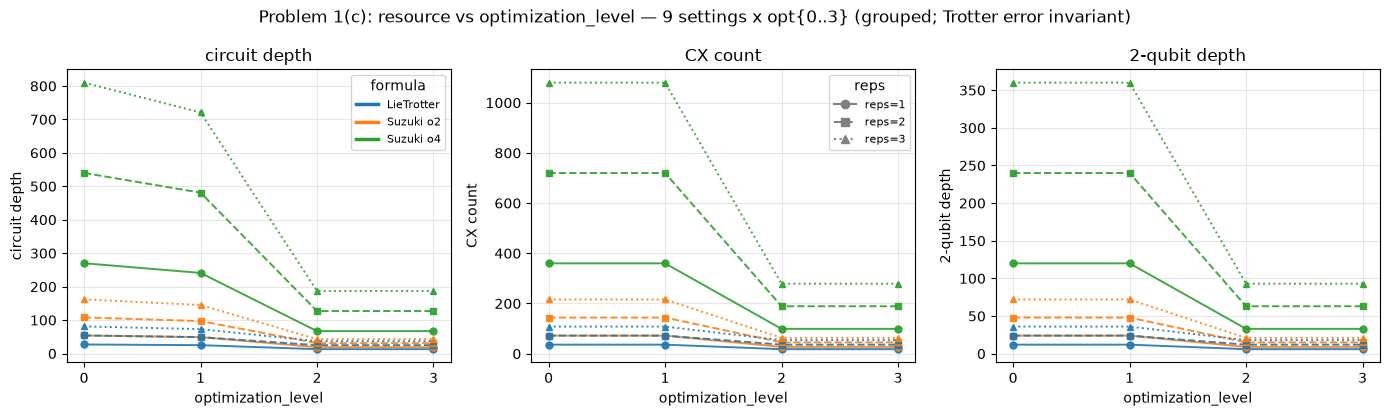

cx_count                        depth                \
opt                             0       1      2      3      0      1      2   
formula       order reps                                                       
LieTrotter    1     1        36.0    36.0   18.0   18.0   27.0   25.0   13.0   
                    2        72.0    72.0   36.0   36.0   54.0   49.0   25.0   
                    3       108.0   108.0   54.0   54.0   81.0   73.0   37.0   
SuzukiTrotter 2     1        72.0    72.0   27.0   27.0   54.0   49.0   19.0   
                    2       144.0   144.0   45.0   45.0  108.0   97.0   31.0   
                    3       216.0   216.0   63.0   63.0  162.0  145.0   43.0   
              4     1       360.0   360.0   99.0   99.0  270.0  241.0   67.0   
                    2       720.0   720.0  189.0  189.0  540.0  481.0  127.0   
                    3      1080.0  1080.0  279.0  279.0  810.0  721.0  187.0   

                                two_qubit_depth                     
opt                           3               0      1     2     3  
formula       order reps                                            
LieTrotter    1     1      13.0            12.0   12.0   6.0   6.0  
                    2      25.0            24.0   24.0  12.0  12.0  
                    3      37.0            36.0   36.0  18.0  18.0  
SuzukiTrotter 2     1      19.0            24.0   24.0   9.0   9.0  
                    2      31.0            48.0   48.0  15.0  15.0  
                    3      43.0            72.0   72.0  21.0  21.0  
              4     1      67.0           120.0  120.0  33.0  33.0  
                    2     127.0           240.0  240.0  63.0  63.0  
                    3     187.0           360.0  360.0  93.0  93.0

In [ ]:
# Full opt-level sweep: all 9 settings x opt {0,1,2,3} (grouped ordering).
sweep_rows = []
for nm, syn in SETTINGS.items():
    for opt in [0, 1, 2, 3]:
        tqc = transpile_to_basis(evolution_circuit(0.5, syn, ordering="grouped"), opt=opt)
        sweep_rows.append(dict(setting=nm, **SETTING_META[nm], opt=opt, **resource_counts(tqc)))
sweep_df = pd.DataFrame(sweep_rows)

# opt-invariance proof across ALL 9 settings (compile ablation => logical unitary unchanged)
def _evo_sv_opt(syn, opt):
    qc = evolution_circuit(0.5, syn, ordering="grouped", include_stateprep=True)
    return Statevector.from_instruction(transpile_to_basis(qc.decompose(), opt=opt)).data
max_dev = 0.0
for nm, syn in SETTINGS.items():
    b = _evo_sv_opt(syn, 0)
    for opt in [1, 2, 3]:
        max_dev = max(max_dev, float(np.max(np.abs(b - _evo_sv_opt(syn, opt)))))
print("opt-invariance: max|delta statevector| over ALL 9 settings x opt1-3 = %.2e  (<=1e-9 => error-preserving)" % max_dev)

from matplotlib.lines import Line2D
order_color = {1: "tab:blue", 2: "tab:orange", 4: "tab:green"}   # LieTrotter / Suzuki-2 / Suzuki-4
reps_fmt    = {1: ("-", "o"), 2: ("--", "s"), 3: (":", "^")}
metrics = [("depth", "circuit depth"), ("cx_count", "CX count"), ("two_qubit_depth", "2-qubit depth")]
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
for ax, (m, lbl) in zip(axes, metrics):
    for nm, meta in SETTING_META.items():
        sub = sweep_df[sweep_df.setting == nm].sort_values("opt")
        ls, mk = reps_fmt[meta["reps"]]
        ax.plot(sub.opt, sub[m], ls=ls, marker=mk, color=order_color[meta["order"]], lw=1.4, ms=5, alpha=.9)
    ax.set_xlabel("optimization_level"); ax.set_ylabel(lbl); ax.set_title(lbl)
    ax.set_xticks([0, 1, 2, 3]); ax.grid(alpha=.3)
leg1 = [Line2D([], [], color=order_color[o], lw=2.5, label=l) for o, l in [(1, "LieTrotter"), (2, "Suzuki o2"), (4, "Suzuki o4")]]
leg2 = [Line2D([], [], color="gray", ls=reps_fmt[k][0], marker=reps_fmt[k][1], label="reps=%d" % k) for k in [1, 2, 3]]
axes[0].legend(handles=leg1, fontsize=8, title="formula", loc="upper right")
axes[1].legend(handles=leg2, fontsize=8, title="reps", loc="upper right")
plt.suptitle("Problem 1(c): resource vs optimization_level — 9 settings x opt{0..3} (grouped; Trotter error invariant)")
plt.tight_layout(); plt.show()
sweep_df.pivot_table(index=["formula", "order", "reps"], columns="opt", values=["depth", "cx_count", "two_qubit_depth"])

## Problem 1(d-f): state and local-observable errors
$\epsilon_{state}=1-|\langle\psi_{ex}|\psi_{PF}\rangle|^2$ (opt-불변 논리량), $\epsilon_O=|\langle O\rangle_{ex}-\langle O\rangle_{PF}|$.

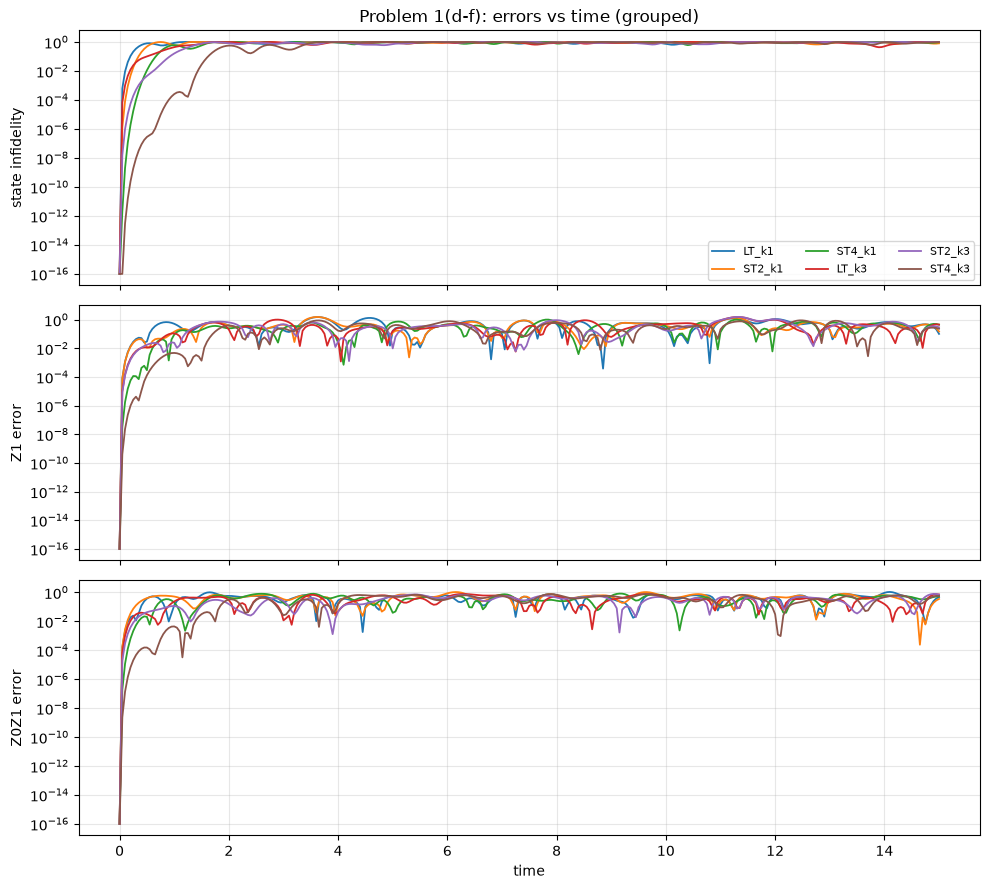

,setting,time,state_infidelity,Z1_error,Z0Z1_error
0,LT_k1,0.00,0.000000,0.000000,0.000000
1,LT_k1,0.05,0.000615,0.000079,0.000155
2,LT_k1,0.10,0.009130,0.001191,0.002177
3,LT_k1,0.15,0.040759,0.005409,0.008682
4,LT_k1,0.20,0.108096,0.014586,0.018756


In [ ]:
PLOT_SETTINGS = ["LT_k1","ST2_k1","ST4_k1","LT_k3","ST2_k3","ST4_k3"]
err_rows = []
for nm in PLOT_SETTINGS:
    syn = SETTINGS[nm]
    for i, t in enumerate(TIMES):
        pf = product_formula_state(t, syn, ordering="grouped")
        inf = float(np.clip(1 - abs(exact_state(t).inner(pf))**2, 0, 1))
        err_rows.append(dict(setting=nm, time=float(t), state_infidelity=inf,
                             Z1_error=abs(exact_z1[i]-expval(pf, Z1_mat)),
                             Z0Z1_error=abs(exact_z0z1[i]-expval(pf, Z0Z1_mat))))
error_table = pd.DataFrame(err_rows)
fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)
for ax, (m, lbl) in zip(axes, [("state_infidelity","state infidelity"),("Z1_error","Z1 error"),("Z0Z1_error","Z0Z1 error")]):
    for nm in PLOT_SETTINGS:
        s = error_table[error_table.setting == nm]
        ax.semilogy(s.time, np.maximum(s[m], 1e-16), label=nm, lw=1.3)
    ax.set_ylabel(lbl); ax.grid(alpha=.3)
axes[0].legend(ncol=3, fontsize=8); axes[-1].set_xlabel("time")
axes[0].set_title("Problem 1(d-f): errors vs time (grouped)"); plt.tight_layout(); plt.show()
error_table.head()

### 단시간 스케일링 검증 + $t^\ast$  (순위 1차 근거)
order-$p$: $\epsilon_{state}\sim t^{2(p+1)}/r^{2p}$. log-log 기울기를 이론과 대조. 약한 설정은 거친 격자에서 즉시 포화하므로 **전용 fine grid**로 fit(ST4는 floor 한계로 부분 검증).

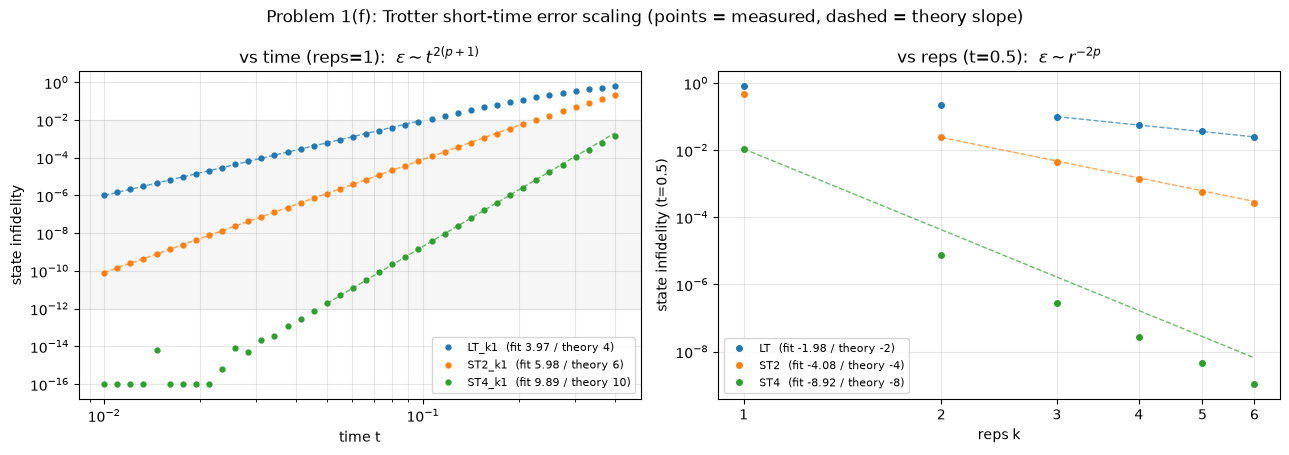

t* (first infidelity>1e-2): {'LT_k1': 0.15, 'ST2_k1': 0.25, 'ST4_k1': 0.5}


,setting,t_star,slope_vs_t,theory_t,slope_vs_reps,theory_reps
0,LT_k1,0.15,3.97,4,-1.98,-2
1,ST2_k1,0.25,5.98,6,-4.08,-4
2,ST4_k1,0.50,9.89,10,-8.92,-8


In [ ]:
import matplotlib.ticker as mticker
def infid(t, syn, ordering="grouped"):
    return float(np.clip(1 - abs(exact_state(t).inner(product_formula_state(t, syn, ordering)))**2, 0, 1))
def make_syn(fam, k):
    return LieTrotter(reps=k) if fam == "LT" else SuzukiTrotter(order=int(fam[2]), reps=k)

tstar = {nm: next((round(float(t), 3) for t in TIMES if infid(t, syn) > 1e-2), None) for nm, syn in SETTINGS.items()}
fine = np.geomspace(0.01, 0.4, 40)
def slope_vs_t(syn):
    xs, ys = [], []
    for t in fine:
        e = infid(t, syn)
        if 1e-13 < e < 1e-2: xs.append(np.log10(t)); ys.append(np.log10(e))
    return round(float(np.polyfit(xs, ys, 1)[0]), 2) if len(xs) > 2 else None
def slope_vs_reps(fam, t=0.5, kmax=6):
    xs, ys = [], []
    for k in range(1, kmax + 1):
        e = infid(t, make_syn(fam, k))
        if 1e-13 < e < 1e-1: xs.append(np.log10(k)); ys.append(np.log10(e))
    return round(float(np.polyfit(xs, ys, 1)[0]), 2) if len(xs) > 2 else None

scaling = pd.DataFrame([
    dict(setting=f, t_star=tstar[f], slope_vs_t=slope_vs_t(SETTINGS[f]), theory_t=tt,
         slope_vs_reps=slope_vs_reps(fam), theory_reps=tr)
    for f, fam, tt, tr in [("LT_k1", "LT", 4, -2), ("ST2_k1", "ST2", 6, -4), ("ST4_k1", "ST4", 10, -8)]])

fams = [("LT_k1", "LT", 4, -2, "tab:blue"), ("ST2_k1", "ST2", 6, -4, "tab:orange"), ("ST4_k1", "ST4", 10, -8, "tab:green")]
fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 4.6))
# left: infidelity vs time (fixed reps=1), measured points + dashed theory slope
for nm, fam, st, _, col in fams:
    ys = np.array([infid(t, SETTINGS[nm]) for t in fine])
    axL.loglog(fine, np.maximum(ys, 1e-16), "o", ms=3.5, color=col,
               label="%s  (fit %s / theory %d)" % (nm, slope_vs_t(SETTINGS[nm]), st))
    m = (ys > 1e-12) & (ys < 1e-2)
    if m.sum() > 1:
        tw = fine[m]; yw = ys[m]; i0 = len(tw) // 2
        axL.loglog(tw, yw[i0] * (tw / tw[i0])**st, "--", color=col, lw=1, alpha=.7)
axL.axhspan(1e-12, 1e-2, color="gray", alpha=.07)
axL.set_xlabel("time t"); axL.set_ylabel("state infidelity")
axL.set_title(r"vs time (reps=1):  $\epsilon \sim t^{2(p+1)}$")
axL.legend(fontsize=8); axL.grid(which="both", alpha=.3)
# right: infidelity vs reps (fixed t=0.5), measured points + dashed theory slope
kk = np.arange(1, 7)
for nm, fam, _, sr, col in fams:
    ys = np.array([infid(0.5, make_syn(fam, k)) for k in kk])
    axR.loglog(kk, np.maximum(ys, 1e-16), "o", ms=4, color=col,
               label="%s  (fit %s / theory %d)" % (fam, slope_vs_reps(fam), sr))
    m = (ys > 1e-12) & (ys < 1e-1)
    if m.sum() > 1:
        kw = kk[m]; yw = ys[m]
        axR.loglog(kw, yw[0] * (kw / kw[0])**sr, "--", color=col, lw=1, alpha=.7)
axR.set_xlabel("reps k"); axR.set_ylabel("state infidelity (t=0.5)")
axR.set_title(r"vs reps (t=0.5):  $\epsilon \sim r^{-2p}$")
axR.set_xticks(kk); axR.xaxis.set_major_formatter(mticker.ScalarFormatter()); axR.xaxis.set_minor_formatter(mticker.NullFormatter())
axR.legend(fontsize=8); axR.grid(which="both", alpha=.3)
plt.suptitle("Problem 1(f): Trotter short-time error scaling (points = measured, dashed = theory slope)")
plt.tight_layout(); plt.show()
print("t* (first infidelity>1e-2):", {k: tstar[k] for k in ["LT_k1", "ST2_k1", "ST4_k1"]})
scaling

### Problem 1(c/h): accuracy-resource Pareto + 토의
x = opt3 compiled depth(HW 비용), y = mean $\epsilon_{state}$($t\le2.0$, 논리량). **순위 1차 근거는 위 기울기·$t^\ast$**; 윈도우 평균은 포화 지배라 보조로만(역전 가능).

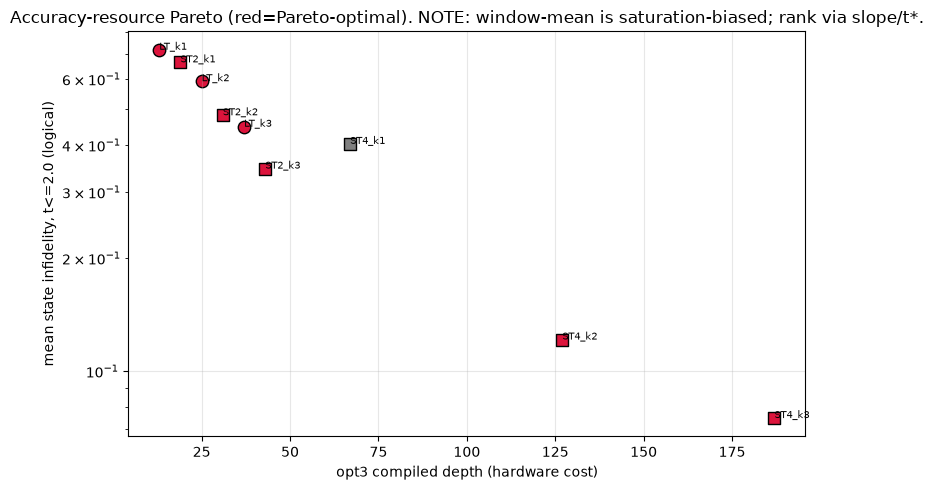

Pareto-optimal settings: ['LT_k1', 'ST2_k1', 'LT_k2', 'ST2_k2', 'ST4_k2', 'LT_k3', 'ST2_k3', 'ST4_k3']


,setting,formula,order,reps,mean_infid,depth,t_star,pareto,scalar_E
0,LT_k1,LieTrotter,1,1,0.717413,13,0.15,True,9.326373
1,ST2_k1,SuzukiTrotter,2,1,0.663986,19,0.25,True,12.615729
2,ST4_k3,SuzukiTrotter,4,3,0.074961,187,1.45,True,14.017786
3,LT_k2,LieTrotter,1,2,0.591515,25,0.15,True,14.787883
4,ST2_k3,SuzukiTrotter,2,3,0.346052,43,0.65,True,14.880249
5,ST2_k2,SuzukiTrotter,2,2,0.480008,31,0.40,True,14.880258
6,ST4_k2,SuzukiTrotter,4,2,0.121310,127,0.95,True,15.406421
7,LT_k3,LieTrotter,1,3,0.447402,37,0.20,True,16.553867
8,ST4_k1,SuzukiTrotter,4,1,0.402686,67,0.50,False,26.979987


In [ ]:
win = TIMES[TIMES <= 2.0]
pareto = []
for nm, syn in SETTINGS.items():
    mi = float(np.mean([infid(t, syn) for t in win]))
    dep = int(resource_grouped.loc[resource_grouped.setting == nm, "depth"].iloc[0])
    pareto.append(dict(setting=nm, **SETTING_META[nm], mean_infid=mi, depth=dep, t_star=tstar[nm]))
pareto = pd.DataFrame(pareto)
def is_pareto(r, df):
    dom = (df.depth <= r.depth) & (df.mean_infid <= r.mean_infid) & ((df.depth < r.depth) | (df.mean_infid < r.mean_infid))
    return not dom.any()
pareto["pareto"] = [is_pareto(r, pareto) for _, r in pareto.iterrows()]
pareto["scalar_E"] = pareto.mean_infid * pareto.depth
fig, ax = plt.subplots(figsize=(8, 5)); mk = {"LieTrotter":"o","SuzukiTrotter":"s"}
for _, r in pareto.iterrows():
    ax.scatter(r.depth, max(r.mean_infid, 1e-6), marker=mk[r.formula], s=80, edgecolor="k",
               color=("crimson" if r.pareto else "gray"))
    ax.annotate(r.setting, (r.depth, max(r.mean_infid, 1e-6)), fontsize=7)
ax.set_yscale("log"); ax.set_xlabel("opt3 compiled depth (hardware cost)")
ax.set_ylabel("mean state infidelity, t<=2.0 (logical)")
ax.set_title("Accuracy-resource Pareto (red=Pareto-optimal). NOTE: window-mean is saturation-biased; rank via slope/t*.")
ax.grid(alpha=.3); plt.tight_layout(); plt.show()
print("Pareto-optimal settings:", list(pareto[pareto.pareto].setting))
pareto.sort_values("scalar_E").reset_index(drop=True)

### N=6 vs N=12 accuracy-resource trade-off (t=0.5, opt=3, grouped)
Problem 1(b,c,d,f)를 **t=0.5 단일 시점, opt=3, ordering=grouped**로 N=6과 N=12에 각각 돌려 trade-off를 비교한다.
- N=6: 기본 모델 ($J_x{=}1,J_y{=}0.7,J_z{=}1.2,h_x{=}0.4$, $|010101\rangle$)
- N=12: 1(g) QPU 모델 ($J_x{=}J_y{=}1,J_z{=}1.2,h_x{=}0$, $|10\cdots0\rangle$)

x = opt3 compiled depth(회로 구조상 N-불변), y = $t{=}0.5$ 상태 infidelity. marker=formula order, color=reps.

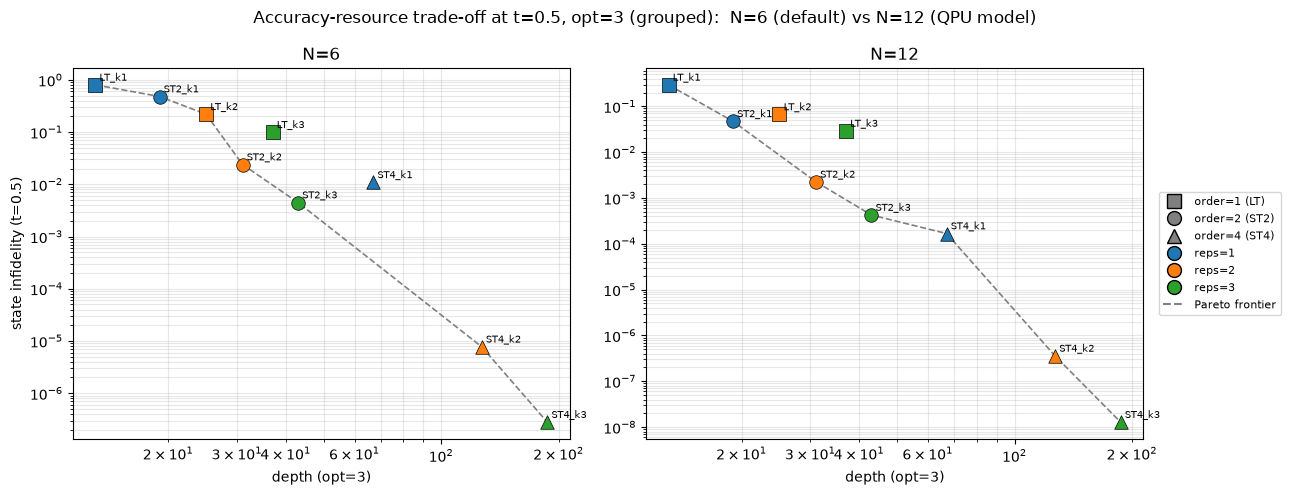

depth           infidelity              
system                     N=12    N=6          N=12           N=6
formula       order reps                                          
LieTrotter    1     1      13.0   13.0  2.950607e-01  8.015722e-01
                    2      25.0   25.0  6.672981e-02  2.194967e-01
                    3      37.0   37.0  2.911604e-02  9.933475e-02
SuzukiTrotter 2     1      19.0   19.0  4.724796e-02  4.797731e-01
                    2      31.0   31.0  2.256066e-03  2.392291e-02
                    3      43.0   43.0  4.254136e-04  4.471092e-03
              4     1      67.0   67.0  1.677587e-04  1.090536e-02
                    2     127.0  127.0  3.572192e-07  7.749437e-06
                    3     187.0  187.0  1.279231e-08  2.788735e-07

In [ ]:
# Trade-off at fixed t=0.5, opt=3, ordering=grouped, for N=6 and N=12.
# x = opt3 compiled depth (evolution-only); y = state infidelity at t=0.5 (single point).
configs = [
    ("N=6",  6,  dict(Jx=1.0, Jy=0.7, Jz=1.2, hx=0.4), "010101"),       # default model, Neel
    ("N=12", 12, dict(Jx=1.0, Jy=1.0, Jz=1.2, hx=0.0), "1" + "0"*11),    # 1(g) QPU model, single excitation
]
rows = []
for label, n, model, bit in configs:
    H = build_heisenberg_hamiltonian(num_qubits=n, ordering="grouped", **model)[0]
    evals, evecs = np.linalg.eigh(H.to_matrix())
    psi0v = Statevector.from_label(bit[::-1]).data         # bit is qubit-0-first; reverse for Qiskit label
    coeff = evecs.conj().T @ psi0v
    exact05 = evecs @ (np.exp(-1j*0.5*evals) * coeff)       # exact e^{-iH*0.5}|psi0>
    for nm, syn in SETTINGS.items():
        qc = QuantumCircuit(n)
        for i, ch in enumerate(bit):
            if ch == "1": qc.x(i)
        qc.append(PauliEvolutionGate(H, time=0.5, synthesis=syn), range(n))
        pf = Statevector.from_instruction(qc.decompose()).data
        inf = float(np.clip(1 - abs(np.vdot(exact05, pf))**2, 0, 1))
        qe = QuantumCircuit(n); qe.append(PauliEvolutionGate(H, time=0.5, synthesis=syn), range(n))
        depth = transpile(qe, basis_gates=BASIS_GATES, optimization_level=3, seed_transpiler=42).depth()
        rows.append(dict(system=label, setting=nm, **SETTING_META[nm], depth=depth, infidelity=inf))
tradeoff05 = pd.DataFrame(rows)

from matplotlib.lines import Line2D
order_marker = {1: "s", 2: "o", 4: "^"}              # formula order -> marker
reps_color   = {1: "tab:blue", 2: "tab:orange", 3: "tab:green"}   # reps -> color
def _pareto(sub):
    out, best = [], np.inf
    for _, r in sub.sort_values("depth").iterrows():
        if r.infidelity < best - 1e-15:
            out.append((r.depth, r.infidelity)); best = r.infidelity
    return np.array(out)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, sysname in zip(axes, ["N=6", "N=12"]):
    sub = tradeoff05[tradeoff05.system == sysname]
    for _, r in sub.iterrows():
        y = max(r.infidelity, 1e-12)
        ax.scatter(r.depth, y, marker=order_marker[r.order], color=reps_color[r.reps],
                   s=95, edgecolor="k", lw=.5, zorder=3)
        ax.annotate(r.setting, (r.depth, y), fontsize=7, xytext=(3, 3), textcoords="offset points")
    fr = _pareto(sub)
    ax.plot(fr[:, 0], np.maximum(fr[:, 1], 1e-12), "--", color="gray", lw=1.2, zorder=2)
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("depth (opt=3)"); ax.set_title(sysname); ax.grid(which="both", alpha=.3)
axes[0].set_ylabel("state infidelity (t=0.5)")
mleg = [Line2D([], [], marker=order_marker[o], color="w", markerfacecolor="gray", markeredgecolor="k",
                ms=10, label=l) for o, l in [(1, "order=1 (LT)"), (2, "order=2 (ST2)"), (4, "order=4 (ST4)")]]
cleg = [Line2D([], [], marker="o", color="w", markerfacecolor=reps_color[k], markeredgecolor="k",
                ms=10, label="reps=%d" % k) for k in [1, 2, 3]]
pleg = [Line2D([], [], ls="--", color="gray", label="Pareto frontier")]
axes[1].legend(handles=mleg + cleg + pleg, fontsize=8, loc="center left", bbox_to_anchor=(1.02, 0.5))
plt.suptitle("Accuracy-resource trade-off at t=0.5, opt=3 (grouped):  N=6 (default) vs N=12 (QPU model)")
plt.tight_layout(); plt.show()
tradeoff05.pivot_table(index=["formula", "order", "reps"], columns="system", values=["depth", "infidelity"])

### Circuit resource scaling vs system size N (grouped, opt=3, t=0.5)

9개 synthesis 설정의 **CX 수·depth를 N=12~52로 스케일링**한 표. 1(g) scale-up의 2Q-예산 break 논리(예: ST2_k3는 N=44에서 2q=462>400, ST2_k2는 N=60에서야 초과)를 뒷받침한다. grouped라 **depth는 N-불변**, CX만 ∝N 증가.

In [ ]:
N_SCALE = [12, 20, 28, 36, 44, 52]
t_scale = 0.5
scale_rows = []
for nm, syn in SETTINGS.items():
    row = {"model": nm}
    for nq in N_SCALE:
        tqc = transpile_to_basis(evolution_circuit(t_scale, syn, ordering="grouped", num_qubits=nq), opt=3)
        row["cx_%d" % nq] = tqc.count_ops().get("cx", 0)
        row["depth_%d" % nq] = tqc.depth()
    scale_rows.append(row)
df_scale = pd.DataFrame(scale_rows).set_index("model")
df_cx    = df_scale[["cx_%d" % n for n in N_SCALE]].copy();    df_cx.columns    = ["N=%d" % n for n in N_SCALE]
df_depth = df_scale[["depth_%d" % n for n in N_SCALE]].copy(); df_depth.columns = ["N=%d" % n for n in N_SCALE]
print("[CX gate count]  ordering=grouped, opt=3, t=0.5")
display(df_cx)
print("[circuit depth]  ordering=grouped, opt=3, t=0.5  (grouped depth is N-invariant)")
display(df_depth)

[CX gate count]  ordering=grouped, opt=3, t=0.5


,N=12,N=20,N=28,N=36,N=44,N=52
model,,,,,,
LT_k1,36,60,84,108,132,156
ST2_k1,54,90,126,162,198,234
ST4_k1,198,330,462,594,726,858
LT_k2,72,120,168,216,264,312
ST2_k2,90,150,210,270,330,390
ST4_k2,378,630,882,1134,1386,1638
LT_k3,108,180,252,324,396,468
ST2_k3,126,210,294,378,462,546
ST4_k3,558,930,1302,1674,2046,2418


[circuit depth]  ordering=grouped, opt=3, t=0.5  (grouped depth is N-invariant)


,N=12,N=20,N=28,N=36,N=44,N=52
model,,,,,,
LT_k1,13,13,13,13,13,13
ST2_k1,19,19,19,19,19,19
ST4_k1,67,67,67,67,67,67
LT_k2,25,25,25,25,25,25
ST2_k2,31,31,31,31,31,31
ST4_k2,127,127,127,127,127,127
LT_k3,37,37,37,37,37,37
ST2_k3,43,43,43,43,43,43
ST4_k3,187,187,187,187,187,187


## Problem 1(g): Run on an IBM Heron backend
$N=12$, $J_x{=}J_y{=}1,J_z{=}1.2,h_x{=}0$, $|10\cdots0\rangle$, $\langle Z_0\rangle$, $t=1.0$, `resilience_level=2`.
exact baseline은 단일여기 부분공간(`utils.single_one_evolution_meas_Z0`).

In [ ]:
N12 = 12
def build_H12(ordering="grouped"):
    allb = [(j, (j+1) % N12) for j in range(N12)]; even, odd = allb[0::2], allb[1::2]; rows = []
    for _, L in [("even", even), ("odd", odd)]:
        for P, c in [("XX", 1.0), ("YY", 1.0), ("ZZ", 1.2)]:
            for (a, b) in L: rows.append((P, [a, b], c))
    return SparsePauliOp.from_sparse_list(rows, num_qubits=N12)

T1G = 1.0
qc12 = QuantumCircuit(N12); qc12.x(0)                          # |10...0>: qubit 0 excited
qc12.append(PauliEvolutionGate(build_H12(), time=T1G, synthesis=SuzukiTrotter(order=2, reps=2)), range(N12))

sv12 = Statevector.from_instruction(qc12.decompose())
Z0_12 = SparsePauliOp.from_list([("I"*(N12-1)+"Z", 1.0)]).to_matrix()
z0_pf = expval(sv12, Z0_12)
z0_exact = utils.single_one_evolution_meas_Z0(T1G)
Nhat = ((N12*SparsePauliOp.from_list([("I"*N12, 1.0)])
         - sum(SparsePauliOp.from_list([("I"*(N12-1-i)+"Z"+"I"*i, 1.0)]) for i in range(N12)))*0.5).to_matrix()
leak = abs(expval(sv12, Nhat) - 1.0)
print("exact <Z0> = %.4f | noiseless PF <Z0> = %.4f | Trotter |diff| = %.4f" % (z0_exact, z0_pf, abs(z0_pf - z0_exact)))
print("symmetry leakage |<N>-1| = %.2e   (~0: grouped preserves number; same-bond XX,YY commute)" % leak)

exact <Z0> = 0.6846 | noiseless PF <Z0> = 0.7846 | Trotter |diff| = 0.1000
symmetry leakage |<N>-1| = 1.35e-14   (~0: grouped preserves number; same-bond XX,YY commute)


### Hard-constraint 판정 + 생존확률 앵커 (별첨 Heron 문서)
Hint 3 예산을 통과해야 실행. 실기 transpile은 `seed_transpiler` 고정(라우팅 결정성).

In [ ]:
# Heron coupling map / native basis. Prefer FakeTorino (Heron r1); fall back to an ideal
# cycle-embedding (basis-only transpile, no routing) if qiskit_ibm_runtime is unavailable.
try:
    from qiskit_ibm_runtime.fake_provider import FakeTorino
    backend = FakeTorino()
    tqc12 = transpile(qc12, backend=backend, optimization_level=3, seed_transpiler=42)
    HW_NOTE = "FakeTorino (Heron r1) coupling map"
except ModuleNotFoundError:
    backend = None
    tqc12 = transpile(qc12, basis_gates=["cz", "rz", "sx", "x"], optimization_level=3, seed_transpiler=42)
    HW_NOTE = "basis-only fallback (ideal cycle embedding; qiskit_ibm_runtime not installed)"
g2  = sum(1 for i in tqc12.data if len(i.qubits) == 2)
tqd = two_qubit_depth(tqc12)
passes = (tqc12.depth() < 100) and (g2 < 400) and (tqd < 30)
e2q = 0.003                       # Heron r2/r3 median 2q error prior
F2q = (1 - e2q) ** g2
print("Hard-constraint  [%s, opt3, seed=42]:" % HW_NOTE)
print("  depth     = %3d  (<100)  %s" % (tqc12.depth(), "PASS" if tqc12.depth() < 100 else "FAIL"))
print("  2q gates  = %3d  (<400)  %s" % (g2, "PASS" if g2 < 400 else "FAIL"))
print("  2q depth  = %3d  (<30 )  %s" % (tqd, "PASS" if tqd < 30 else "FAIL"))
print("  => runnable:", passes)
print("Survival anchor  F2q = (1-%.3f)^%d = %.3f" % (e2q, g2, F2q))
print("  [2q-only UPPER BOUND: excludes 1q error (0.03-0.08%/gate) and idle T1/T2 decoherence]")

Hard-constraint  [FakeTorino (Heron r1) coupling map, opt3, seed=42]:
  depth     =  63  (<100)  PASS
  2q gates  =  90  (<400)  PASS
  2q depth  =  15  (<30 )  PASS
  => runnable: True
Survival anchor  F2q = (1-0.003)^90 = 0.763
  [2q-only UPPER BOUND: excludes 1q error (0.03-0.08%/gate) and idle T1/T2 decoherence]


### Challenge: ST2_k3 scale-up on **real IBM Heron** — reps-controlled boundary + subring-seeded noncyclic layout search (N = 4 + 8r)

**이 셀은 실제 IBM Heron QPU에서 직접 실행된다.** 토큰은 환경변수 `IBM_QUANTUM_TOKEN`(또는 저장된 계정)을 우선 사용한다.

Break hierarchy is now intentionally separated:
1. **Primary scalability break (free, no QPU, no ring selection)** — backend capacity -> deterministic logical resource counts -> Hint 3 budget. This is the only source of `break_info`.
2. **Supplementary QPU layout/measurement** — for N values that passed the primary scan, use calibration-weighted subring seeds, noncyclic patch expansion, and final length-N ring/near-cycle extraction. Ring/near-cycle quality is recorded as metadata and never decides the first break.

This keeps the reps sweep focused on N-scalability: k2 vs k3 differs through the 2Q budget, while the layout selector is a quality annotation/optimization for submitted jobs. Overlapping subrings are merged by unique qubits/edges before final extraction, so shared qubits are not double-counted.

> If a QPU job fails, `qpu_stop_info` is recorded and later N values remain in the resource table without more submissions; the primary `break_info` is unchanged.


qiskit_runtime_service._discover_account:WARNING:2026-06-30 16:21:39,409: Loading account with the given token. A saved account will not be used.


backend: ibm_aachen | qubits: 156 | source: pinned_backend
ST2_k3 N= 12 PASS primary: depth=43 2q=126 2q-depth=21 | exact <Z0>=0.6846
ST2_k3 N= 20 PASS primary: depth=43 2q=210 2q-depth=21 | exact <Z0>=0.6845
ST2_k3 N= 28 PASS primary: depth=43 2q=294 2q-depth=21 | exact <Z0>=0.6845
ST2_k3 N= 36 PASS primary: depth=43 2q=378 2q-depth=21 | exact <Z0>=0.6845
RESOURCE BREAK at N=44 (r=5): 2q-count 462>=400  -> primary stop, no ring/QPU involved
ST2_k3 N= 12 QPU pair: default <Z0>=0.74193 | beam <Z0>=0.69942 | delta |err|=-0.04251
ST2_k3 N= 20 QPU pair: default <Z0>=0.73906 | beam <Z0>=0.68455 | delta |err|=-0.05451
ST2_k3 N= 28 QPU pair: default <Z0>=0.68861 | beam <Z0>=0.72164 | delta |err|=0.03302
ST2_k3 N= 36 QPU pair: default <Z0>=0.70232 | beam <Z0>=0.70418 | delta |err|=0.00186

=> primary break point: N=44 at stage 'resource' (2q-count 462>=400)
Scaling measurement result: default layout vs calibrated beam ring selection


,label,reps,N,layout_mode,status,z0_exact,z0_measured,abs_err_vs_exact,delta_z0_measured_vs_default,delta_abs_err_vs_exact_vs_default,qpu_depth,qpu_two_q,qpu_two_q_depth,delta_qpu_depth_vs_default,delta_qpu_two_q_vs_default,delta_qpu_two_q_depth_vs_default,ring_survival,native_ring,closure_distance,selected_mean_2q_error,selected_worst_2q_error,ring_candidates,selector_runtime_sec,calibration_source,calibration_backend,ring_selector,layout_note,selected_ring_qubits,measurement_source
0,ST2_k3,3,12,default_layout,ok,0.684564,0.741930,0.057366,-0.042509,-0.042509,86,126,21,1,0,0,NaN,NaN,NaN,NaN,NaN,0,4.589965e-07,refreshed_backend_target,ibm_aachen,default_transpiler_layout,default transpiler layout; no calibrated ring selection,not applicable,heron(resilience=2)
1,ST2_k3,3,12,calibrated_beam,ok,0.684564,0.699421,0.014857,-0.042509,-0.042509,87,126,21,1,0,0,0.989066,True,1.0,0.000916,0.001450,5916,3.219883e-02,refreshed_backend_target,ibm_aachen,calibrated_beam_native_ring,"calibrated beam initial_layout, native ring","[131, 138, 151, 152, 153, 154, 155, 139, 135, 134, 133, 132]",heron(resilience=2)
2,ST2_k3,3,20,default_layout,ok,0.684544,0.739063,0.054519,-0.054509,-0.054509,87,210,21,-1,0,0,NaN,NaN,NaN,NaN,NaN,0,7.625000e-06,refreshed_backend_target,ibm_aachen,default_transpiler_layout,default transpiler layout; no calibrated ring selection,not applicable,heron(resilience=2)
3,ST2_k3,3,20,calibrated_beam,ok,0.684544,0.684555,0.000010,-0.054509,-0.054509,86,210,21,-1,0,0,0.961836,True,1.0,0.001942,0.009427,18418,2.156777e-01,refreshed_backend_target,ibm_aachen,calibrated_beam_native_ring,"calibrated beam initial_layout, native ring","[77, 65, 64, 63, 62, 61, 76, 81, 82, 83, 96, 103, 104, 105, 106, 107, 97, 87, 86, 85]",heron(resilience=2)
4,ST2_k3,3,28,default_layout,ok,0.684544,0.688612,0.004068,0.033025,0.033025,87,294,21,3,0,0,NaN,NaN,NaN,NaN,NaN,0,7.500057e-07,refreshed_backend_target,ibm_aachen,default_transpiler_layout,default transpiler layout; no calibrated ring selection,not applicable,heron(resilience=2)
5,ST2_k3,3,28,calibrated_beam,ok,0.684544,0.721636,0.037092,0.033025,0.033025,90,294,21,3,0,0,0.944417,True,1.0,0.002039,0.009427,17599,4.688087e-01,refreshed_backend_target,ibm_aachen,calibrated_beam_native_ring,"calibrated beam initial_layout, native ring","[43, 44, 45, 46, 47, 57, 67, 66, 65, 77, 85, 86, 87, 97, 107, 106, 105, 104, 103, 96, 83, 82, 81, 76, 61, 62, 63, 56]",heron(resilience=2)
6,ST2_k3,3,36,default_layout,ok,0.684544,0.702318,0.017774,0.001863,0.001863,87,378,21,0,0,0,NaN,NaN,NaN,NaN,NaN,0,3.339956e-07,refreshed_backend_target,ibm_aachen,default_transpiler_layout,default transpiler layout; no calibrated ring selection,not applicable,heron(resilience=2)
7,ST2_k3,3,36,calibrated_beam,ok,0.684544,0.704181,0.019637,0.001863,0.001863,87,378,21,0,0,0,0.924556,True,1.0,0.002175,0.009427,17254,7.153767e-01,refreshed_backend_target,ibm_aachen,calibrated_beam_native_ring,"calibrated beam initial_layout, native ring","[57, 67, 66, 65, 77, 85, 86, 87, 97, 107, 106, 105, 104, 103, 96, 83, 82, 81, 76, 61, 62, 63, 56, 43, 44, 45, 37, 25, 26, 27, 28, 29, 38, 49, 48, 47]",heron(resilience=2)


ST2_k3 calibrated beam effect: |err| improved 2 / worsened 2 / tied 0; mean delta |err|=-0.015533; mean delta 2q=0


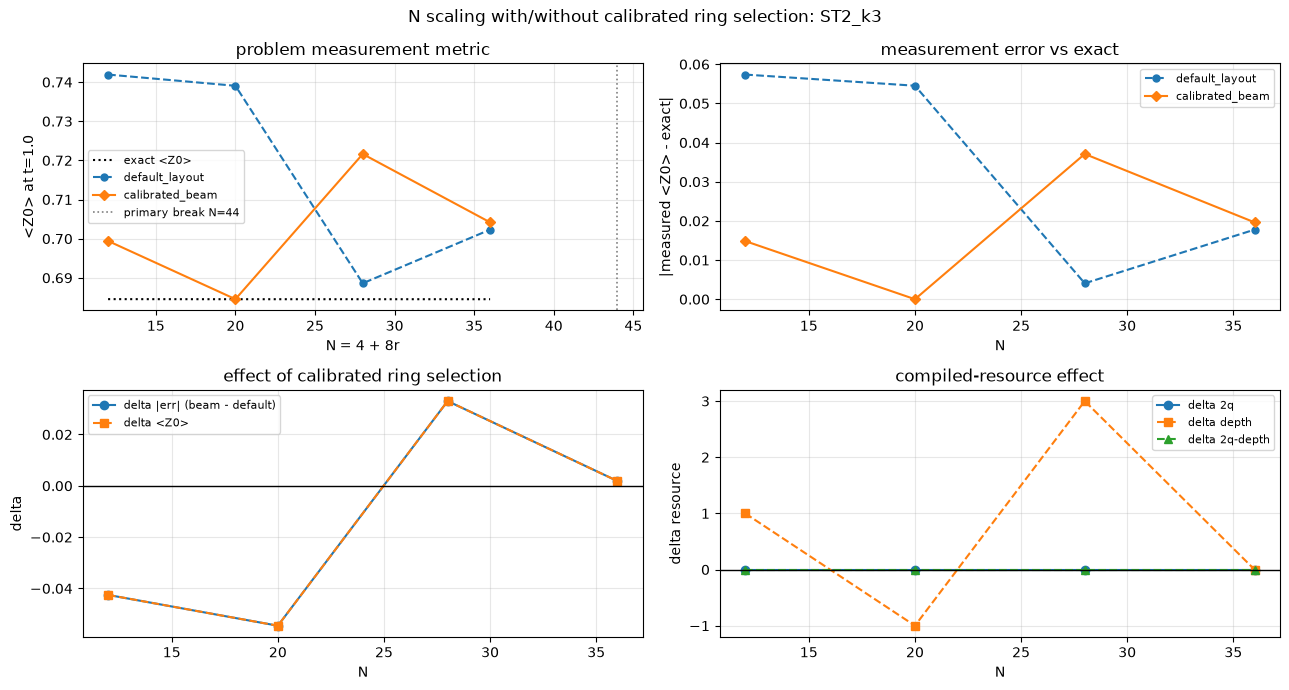

In [ ]:
# ============================================================
# Challenge: reps-controlled ST2_k3 scale-up on IBM Heron QPU, N = 4 + 8r.
# Primary break: capacity / logical resources / Hint 3 budget only.
# Intervention under test: calibrated beam qubit-ring selection on/off.
# Outcome metrics: measured <Z0>, |<Z0> - exact|, and transpiled QPU resources.
# ============================================================
import os
import time
from qiskit_ibm_runtime import QiskitRuntimeService, Session, EstimatorV2

# Use env vars or a saved IBM account. To paste manually, assign IBM_TOKEN below before running.
IBM_TOKEN    = os.environ.get("IBM_QUANTUM_TOKEN", os.environ.get("IBM_TOKEN", ""))
IBM_INSTANCE = os.environ.get("IBM_QUANTUM_INSTANCE", "") or None
BACKEND_NAME = os.environ.get("IBM_BACKEND_NAME", "ibm_aachen").strip() or None  # optional pin, e.g. "ibm_aachen"
BACKEND_MIN_QUBITS = int(os.environ.get("IBM_BACKEND_MIN_QUBITS", "127"))

SCALE_T     = 1.0
SCALE_J     = dict(j_x=1.0, j_y=1.0, j_z=1.2, h_x=0.0)  # 1(g) QPU model
BUDGET      = dict(depth=100, two_q=400, two_q_depth=30)  # Hint 3: strict < each value
RESOURCE_BASIS_GATES = BASIS_GATES                       # deterministic logical-resource scan
SHOTS       = 4096
R_MAX       = 16                                         # safety cap (N <= 132)
RUN_QPU_SCALING = True                                  # True submits both layout modes for each primary-passing N
REFRESH_CALIBRATION_PER_LAYOUT = True                    # refresh backend.target before each N's layout selection
LAYOUT_MODES = ("default_layout", "calibrated_beam")

# Calibrated beam search hyperparameters. This is the single ring-selection model used here.
RING_BEAM_WIDTH = 128
RING_CLOSURE_WEIGHT = 0.03
RING_READOUT_WEIGHT = 0.05
RING_MAX_CLOSURE_DISTANCE = 3

_svc_kwargs = dict(channel="ibm_quantum_platform")
if IBM_TOKEN:
    _svc_kwargs["token"] = IBM_TOKEN
if IBM_INSTANCE:
    _svc_kwargs["instance"] = IBM_INSTANCE
service = QiskitRuntimeService(**_svc_kwargs)

def _backend_label(b):
    name = getattr(b, "name", None)
    return str(name() if callable(name) else name if name is not None else b)

def _has_twoq_target(b):
    try:
        return any(g in b.target.operation_names for g in ("cz", "ecr", "cx"))
    except Exception:
        return True

def _available_backend_summary(service, limit=12):
    try:
        backends = service.backends(operational=True)
    except TypeError:
        backends = service.backends()
    rows = sorted((_backend_label(b), getattr(b, "num_qubits", "?")) for b in backends)
    return ", ".join("%s(%s q)" % row for row in rows[:limit]) + (" ..." if len(rows) > limit else "")

def resolve_backend(service, requested_name=None, min_qubits=127):
    if requested_name:
        try:
            return service.backend(requested_name), "pinned_backend"
        except Exception as exc:
            print("Pinned backend %r unavailable in this account/instance: %r" % (requested_name, exc))
            print("Falling back to least_busy/listed backend.")
    try:
        return service.least_busy(operational=True, min_num_qubits=min_qubits), "least_busy_fallback"
    except Exception as exc:
        print("least_busy(min_num_qubits=%d) failed: %r" % (min_qubits, exc))
    try:
        candidates = service.backends(operational=True)
    except TypeError:
        candidates = service.backends()
    candidates = [b for b in candidates if getattr(b, "num_qubits", 0) >= min_qubits and _has_twoq_target(b)]
    if not candidates:
        raise RuntimeError("No operational backend with >=%d qubits and 2Q target found. Available: %s" %
                           (min_qubits, _available_backend_summary(service)))
    candidates.sort(key=lambda b: (getattr(b, "num_qubits", 0), _backend_label(b)))
    return candidates[0], "listed_backend_fallback"

backend, BACKEND_SOURCE = resolve_backend(service, BACKEND_NAME, BACKEND_MIN_QUBITS)
BACKEND_REFRESH_NAME = _backend_label(backend)
print("backend:", BACKEND_REFRESH_NAME, "| qubits:", backend.num_qubits, "| source:", BACKEND_SOURCE)

def latest_backend_for_layout():
    if not REFRESH_CALIBRATION_PER_LAYOUT:
        return backend, "initial_backend_target"
    try:
        return service.backend(BACKEND_REFRESH_NAME), "refreshed_backend_target"
    except Exception as exc:
        print("Calibration refresh for %s failed: %r; using initial backend target." % (BACKEND_REFRESH_NAME, exc))
        return backend, "initial_backend_target_refresh_failed"

def _twoq_count(tqc):
    return sum(1 for inst in tqc.data if len(inst.qubits) == 2)

def _scale_resources(tqc):
    return dict(qpu_depth=tqc.depth(), qpu_two_q=_twoq_count(tqc), qpu_two_q_depth=two_qubit_depth(tqc))

def _edge_key(a, b):
    return tuple(sorted((int(a), int(b))))

def _target_error_maps(backend):
    target = backend.target
    twoq = next((g for g in ("cz", "ecr", "cx") if g in target.operation_names), None)
    if twoq is None:
        raise RuntimeError("backend target has no cz/ecr/cx operation")
    edge_err = {}
    for qargs, props in sorted(target[twoq].items(), key=lambda item: tuple(item[0])):
        if props is None or props.error is None or len(qargs) != 2:
            continue
        key = _edge_key(*qargs)
        edge_err[key] = min(edge_err.get(key, float("inf")), float(props.error))
    readout_err = {}
    if "measure" in target.operation_names:
        for qargs, props in sorted(target["measure"].items(), key=lambda item: tuple(item[0])):
            if props is not None and props.error is not None and len(qargs) == 1:
                readout_err[int(qargs[0])] = float(props.error)
    return edge_err, readout_err

def _beam_graph(edge_err, readout_err):
    edge_cost = {edge: -np.log(max(1e-12, 1.0 - err)) for edge, err in edge_err.items()}
    adjacency = {q: [] for edge in edge_err for q in edge}
    for a, b in sorted(edge_err):
        adjacency[a].append(b)
        adjacency[b].append(a)
    for q in adjacency:
        adjacency[q] = sorted(adjacency[q], key=lambda nb: (edge_cost[_edge_key(q, nb)], readout_err.get(nb, 0.0), nb))
    return adjacency, edge_cost

def _distances_from(adjacency, start):
    dist = {start: 0}
    queue = [start]
    for node in queue:
        for nb in adjacency.get(node, []):
            if nb not in dist:
                dist[nb] = dist[node] + 1
                queue.append(nb)
    return dist

def _path_edges(path, include_closure):
    edges = [_edge_key(path[i], path[i + 1]) for i in range(len(path) - 1)]
    if include_closure and path:
        edges.append(_edge_key(path[-1], path[0]))
    return edges

def _path_survival(path, edge_err, include_closure):
    edges = _path_edges(path, include_closure)
    return float(np.prod([1.0 - edge_err[e] for e in edges])) if edges else np.nan

def _selected_edge_stats(path, edge_err, include_closure):
    edges = _path_edges(path, include_closure)
    vals = [edge_err[e] for e in edges if e in edge_err]
    return dict(selected_mean_2q_error=(float(np.mean(vals)) if vals else np.nan),
                selected_worst_2q_error=(float(np.max(vals)) if vals else np.nan))

def _format_qubits(layout, max_items=64):
    if layout is None:
        return "None"
    vals = list(map(int, layout))
    if len(vals) <= max_items:
        return "[" + ", ".join(map(str, vals)) + "]"
    head = ", ".join(map(str, vals[:max_items // 2]))
    tail = ", ".join(map(str, vals[-max_items // 2:]))
    return "[%s, ..., %s]" % (head, tail)

def calibrated_beam_ring(backend, ring_len):
    # Single calibrated ring-selection algorithm used in this experiment.
    # It weights individual backend 2Q calibration errors in real time for layout selection.
    edge_err, readout_err = _target_error_maps(backend)
    adjacency, edge_cost = _beam_graph(edge_err, readout_err)
    if ring_len > len(adjacency):
        return dict(layout=None, ring_survival=np.nan, ring_candidates=0, native_ring=False,
                    closure_distance=np.inf, ring_score=np.inf, ring_selector="calibrated_beam_no_candidate",
                    selected_mean_2q_error=np.nan, selected_worst_2q_error=np.nan,
                    selected_ring_qubits="None")

    best_native, best_near = None, None
    complete_candidates = 0
    starts = sorted(adjacency, key=lambda q: (readout_err.get(q, 0.0), q))
    for start in starts:
        dist_to_start = _distances_from(adjacency, start)
        beam = [(0.0, readout_err.get(start, 0.0), (start,))]
        for _ in range(1, ring_len):
            expanded = []
            for ecost, rcost, path in beam:
                last = path[-1]
                used = set(path)
                for nb in adjacency.get(last, []):
                    if nb in used:
                        continue
                    new_path = path + (nb,)
                    new_ecost = ecost + edge_cost[_edge_key(last, nb)]
                    new_rcost = rcost + readout_err.get(nb, 0.0)
                    closure_distance = dist_to_start.get(nb, ring_len + 1)
                    partial_score = (new_ecost + RING_READOUT_WEIGHT * new_rcost
                                     + RING_CLOSURE_WEIGHT * closure_distance)
                    expanded.append((partial_score, new_ecost, new_rcost, new_path))
            if not expanded:
                beam = []
                break
            expanded.sort(key=lambda item: (item[0], item[3]))
            beam = [(ecost, rcost, path) for _, ecost, rcost, path in expanded[:RING_BEAM_WIDTH]]
        for ecost, rcost, path in beam:
            complete_candidates += 1
            last = path[-1]
            close_edge = _edge_key(last, start)
            closure_distance = dist_to_start.get(last, ring_len + 1)
            if close_edge in edge_cost:
                total_ecost = ecost + edge_cost[close_edge]
                score = total_ecost + RING_READOUT_WEIGHT * rcost
                candidate = (score, path, total_ecost, 1)
                if best_native is None or (score, path) < (best_native[0], best_native[1]):
                    best_native = candidate
            elif closure_distance <= RING_MAX_CLOSURE_DISTANCE:
                score = (ecost + RING_READOUT_WEIGHT * rcost
                         + RING_CLOSURE_WEIGHT * closure_distance)
                candidate = (closure_distance, score, path, ecost)
                if best_near is None or (closure_distance, score, path) < (best_near[0], best_near[1], best_near[2]):
                    best_near = candidate

    if best_native is not None:
        score, path, total_ecost, closure_distance = best_native
        stats = _selected_edge_stats(path, edge_err, include_closure=True)
        return dict(layout=list(path), ring_survival=_path_survival(path, edge_err, include_closure=True),
                    ring_candidates=complete_candidates, native_ring=True, closure_distance=closure_distance,
                    ring_score=float(score), ring_selector="calibrated_beam_native_ring",
                    selected_ring_qubits=_format_qubits(path), **stats)
    if best_near is not None:
        closure_distance, score, path, ecost = best_near
        stats = _selected_edge_stats(path, edge_err, include_closure=False)
        return dict(layout=list(path), ring_survival=_path_survival(path, edge_err, include_closure=False),
                    ring_candidates=complete_candidates, native_ring=False, closure_distance=int(closure_distance),
                    ring_score=float(score), ring_selector="calibrated_beam_near_cycle",
                    selected_ring_qubits=_format_qubits(path), **stats)
    return dict(layout=None, ring_survival=np.nan, ring_candidates=complete_candidates, native_ring=False,
                closure_distance=np.inf, ring_score=np.inf, ring_selector="calibrated_beam_no_candidate",
                selected_mean_2q_error=np.nan, selected_worst_2q_error=np.nan,
                selected_ring_qubits="None")

def build_H_scale(n):
    allb = [(j, (j + 1) % n) for j in range(n)]
    even, odd = allb[0::2], allb[1::2]
    rows = []
    for layer in (even, odd):
        for P, c in [("XX", SCALE_J["j_x"]), ("YY", SCALE_J["j_y"]), ("ZZ", SCALE_J["j_z"] )]:
            for a, b in layer:
                rows.append((P, [a, b], c))
    return SparsePauliOp.from_sparse_list(rows, num_qubits=n)

def scale_circuit(n, synthesis):
    qc = QuantumCircuit(n)
    qc.x(0)  # |10...0>
    qc.append(PauliEvolutionGate(build_H_scale(n), time=SCALE_T, synthesis=synthesis), range(n))
    return qc

def resource_feasibility(n, synthesis):
    # Primary Stage: no QPU and no ring selection. This alone determines break_info.
    if n > backend.num_qubits:
        return False, dict(stage="capacity", reason="N=%d exceeds backend qubits (%d)" % (n, backend.num_qubits))
    logical_tqc = transpile(scale_circuit(n, synthesis), basis_gates=RESOURCE_BASIS_GATES,
                            optimization_level=3, seed_transpiler=42)
    info = dict(depth=logical_tqc.depth(), two_q=_twoq_count(logical_tqc), two_q_depth=two_qubit_depth(logical_tqc))
    fails = []
    if info["depth"]       >= BUDGET["depth"]:       fails.append("depth %d>=%d" % (info["depth"], BUDGET["depth"]))
    if info["two_q"]       >= BUDGET["two_q"]:       fails.append("2q-count %d>=%d" % (info["two_q"], BUDGET["two_q"]))
    if info["two_q_depth"] >= BUDGET["two_q_depth"]: fails.append("2q-depth %d>=%d" % (info["two_q_depth"], BUDGET["two_q_depth"]))
    info.update(stage="resource", reason=("; ".join(fails) if fails else "pass"))
    return (len(fails) == 0), info

def scan_resource_boundary(label, synthesis):
    rows, break_info = [], None
    for r in range(1, R_MAX + 1):
        n = 4 + 8 * r
        ok, info = resource_feasibility(n, synthesis)
        if not ok:
            break_info = dict(N=n, r=r, stage=info["stage"], reason=info["reason"])
            print("RESOURCE BREAK at N=%d (r=%d): %s  -> primary stop, no ring/QPU involved" % (n, r, info["reason"]))
            break
        exact_z0 = utils.single_one_evolution_meas_Z0(SCALE_T, num_qubits=n, **SCALE_J)
        rows.append(dict(label=label, N=n, r=r, z0_exact=exact_z0, **info))
        print("%s N=%3d PASS primary: depth=%d 2q=%d 2q-depth=%d | exact <Z0>=%.4f"
              % (label, n, info["depth"], info["two_q"], info["two_q_depth"], exact_z0))
    return pd.DataFrame(rows), break_info

def transpile_for_layout_mode(n, synthesis, layout_mode, layout_backend):
    if layout_mode not in LAYOUT_MODES:
        raise ValueError("unknown layout_mode: %r" % (layout_mode,))
    qc = scale_circuit(n, synthesis)
    t0 = time.perf_counter()
    if layout_mode == "calibrated_beam":
        selection = calibrated_beam_ring(layout_backend, n)
        selector_runtime = time.perf_counter() - t0
        layout = selection.pop("layout")
        if layout is None:
            tqc = transpile(qc, backend=layout_backend, optimization_level=3, seed_transpiler=42)
            selection["layout_note"] = "beam found no candidate; default routed layout used"
        else:
            tqc = transpile(qc, backend=layout_backend, initial_layout=layout, optimization_level=3, seed_transpiler=42)
            selection["layout_note"] = ("calibrated beam initial_layout, native ring"
                                        if selection["native_ring"] else
                                        "calibrated beam initial_layout, near-cycle boundary routed")
        selection["selected_ring_qubits"] = selection.get("selected_ring_qubits", _format_qubits(layout))
    else:
        selector_runtime = time.perf_counter() - t0
        tqc = transpile(qc, backend=layout_backend, optimization_level=3, seed_transpiler=42)
        selection = dict(ring_selector="default_transpiler_layout", ring_survival=np.nan,
                         ring_candidates=0, native_ring=np.nan, closure_distance=np.nan,
                         ring_score=np.nan, selected_mean_2q_error=np.nan,
                         selected_worst_2q_error=np.nan, selected_ring_qubits="not applicable",
                         layout_note="default transpiler layout; no calibrated ring selection")
    metrics = _scale_resources(tqc)
    metrics.update(layout_mode=layout_mode, uses_calibrated_beam=(layout_mode == "calibrated_beam"),
                   selector_runtime_sec=selector_runtime, **selection)
    return tqc, metrics

def z0_observable_for_layout(n, tqc):
    return SparsePauliOp.from_list([("I" * (n - 1) + "Z", 1.0)]).apply_layout(tqc.layout)

def add_delta_columns(result_table):
    if result_table is None or result_table.empty:
        return result_table
    out = result_table.copy()
    metrics = ["z0_measured", "abs_err_vs_exact", "qpu_depth", "qpu_two_q", "qpu_two_q_depth"]
    ok = out[out.status == "ok"]
    if ok.empty:
        return out
    wide = ok.pivot_table(index=["label", "N"], columns="layout_mode", values=metrics, aggfunc="first")
    for metric in metrics:
        if (metric, "calibrated_beam") not in wide or (metric, "default_layout") not in wide:
            continue
        delta = wide[(metric, "calibrated_beam")] - wide[(metric, "default_layout")]
        delta_map = delta.to_dict()
        out["delta_%s_vs_default" % metric] = [delta_map.get((row.label, row.N), np.nan) for row in out.itertuples()]
    return out

SCALING_RESULTS = {}
PRIMARY_SCALING_TABLES = {}

def run_layout_scaling_measurements(label, reps, primary_table):
    if primary_table.empty:
        return pd.DataFrame(), None
    if not RUN_QPU_SCALING:
        raise RuntimeError("RUN_QPU_SCALING is False. This cell is now measurement-focused; enable it to run the scaling experiment.")

    synthesis = SuzukiTrotter(order=2, reps=reps)
    result_rows = []
    qpu_stop_info = None
    with Session(backend=backend) as session:
        estimator = EstimatorV2(mode=session)
        estimator.options.resilience_level = 2
        estimator.options.default_shots = SHOTS
        for base in primary_table.to_dict("records"):
            n, r = int(base["N"]), int(base["r"])
            layout_backend, calibration_source = latest_backend_for_layout()
            circuits, metrics_by_mode = {}, {}
            try:
                for mode in LAYOUT_MODES:
                    tqc, metrics = transpile_for_layout_mode(n, synthesis, mode, layout_backend)
                    circuits[mode] = tqc
                    metrics_by_mode[mode] = metrics
                pubs = [(circuits[mode], z0_observable_for_layout(n, circuits[mode])) for mode in LAYOUT_MODES]
                qpu_result = estimator.run(pubs).result()
                for i, mode in enumerate(LAYOUT_MODES):
                    z0 = float(qpu_result[i].data.evs)
                    abs_err = abs(z0 - float(base["z0_exact"]))
                    result_rows.append(dict(label=label, reps=reps, N=n, r=r, status="ok",
                                            z0_exact=base["z0_exact"], z0_measured=z0,
                                            abs_err_vs_exact=abs_err, measurement_source="heron(resilience=2)",
                                            calibration_source=calibration_source,
                                            calibration_backend=_backend_label(layout_backend),
                                            logical_depth=base["depth"], logical_two_q=base["two_q"],
                                            logical_two_q_depth=base["two_q_depth"],
                                            **metrics_by_mode[mode]))
                print("%s N=%3d QPU pair: default <Z0>=%.5f | beam <Z0>=%.5f | delta |err|=%.5f"
                      % (label, n, result_rows[-2]["z0_measured"], result_rows[-1]["z0_measured"],
                         result_rows[-1]["abs_err_vs_exact"] - result_rows[-2]["abs_err_vs_exact"]))
            except Exception as exc:
                qpu_stop_info = dict(N=n, r=r, stage="qpu_layout_pair", reason=repr(exc))
                for mode in LAYOUT_MODES:
                    partial = metrics_by_mode.get(mode, dict(layout_mode=mode, uses_calibrated_beam=(mode == "calibrated_beam")))
                    result_rows.append(dict(label=label, reps=reps, N=n, r=r, status="error",
                                            z0_exact=base["z0_exact"], z0_measured=np.nan,
                                            abs_err_vs_exact=np.nan, measurement_source=repr(exc),
                                            calibration_source=calibration_source if "calibration_source" in locals() else "unknown",
                                            calibration_backend=_backend_label(layout_backend) if "layout_backend" in locals() else "unknown",
                                            logical_depth=base["depth"], logical_two_q=base["two_q"],
                                            logical_two_q_depth=base["two_q_depth"], error=repr(exc), **partial))
                print("QPU STOP at %s N=%d (r=%d): %r" % (label, n, r, exc))
                break
    return add_delta_columns(pd.DataFrame(result_rows)), qpu_stop_info

def display_scaling_result_table(result_table):
    if result_table.empty:
        return result_table
    cols = ["label", "reps", "N", "layout_mode", "status", "z0_exact", "z0_measured", "abs_err_vs_exact",
            "delta_z0_measured_vs_default", "delta_abs_err_vs_exact_vs_default",
            "qpu_depth", "qpu_two_q", "qpu_two_q_depth", "delta_qpu_depth_vs_default",
            "delta_qpu_two_q_vs_default", "delta_qpu_two_q_depth_vs_default",
            "ring_survival", "native_ring", "closure_distance", "selected_mean_2q_error",
            "selected_worst_2q_error", "ring_candidates", "selector_runtime_sec",
            "calibration_source", "calibration_backend", "ring_selector", "layout_note", "selected_ring_qubits", "measurement_source"]
    present = [c for c in cols if c in result_table.columns]
    shown = result_table[present].copy()
    print("Scaling measurement result: default layout vs calibrated beam ring selection")
    with pd.option_context("display.max_columns", None, "display.max_colwidth", 220, "display.width", 260):
        display(shown)
    return shown

def plot_scaling_results(result_table, primary_table, label, break_info=None):
    if result_table.empty:
        return
    ok = result_table[result_table.status == "ok"].copy()
    if ok.empty:
        print("Plot skipped: no successful QPU measurement rows.")
        return
    fig, axes = plt.subplots(2, 2, figsize=(13, 7))

    ax = axes[0, 0]
    ax.plot(primary_table.N, primary_table.z0_exact, "k:", label="exact <Z0>")
    for mode, style in [("default_layout", "o--"), ("calibrated_beam", "D-")]:
        sub = ok[ok.layout_mode == mode].sort_values("N")
        ax.plot(sub.N, sub.z0_measured, style, ms=5, label=mode)
    if break_info is not None:
        ax.axvline(break_info["N"], color="gray", ls=":", lw=1.2, label="primary break N=%d" % break_info["N"])
    ax.set_xlabel("N = 4 + 8r")
    ax.set_ylabel("<Z0> at t=1.0")
    ax.set_title("problem measurement metric")
    ax.legend(fontsize=8)
    ax.grid(alpha=.3)

    ax = axes[0, 1]
    for mode, style in [("default_layout", "o--"), ("calibrated_beam", "D-")]:
        sub = ok[ok.layout_mode == mode].sort_values("N")
        ax.plot(sub.N, sub.abs_err_vs_exact, style, ms=5, label=mode)
    ax.set_xlabel("N")
    ax.set_ylabel("|measured <Z0> - exact|")
    ax.set_title("measurement error vs exact")
    ax.legend(fontsize=8)
    ax.grid(alpha=.3)

    ax = axes[1, 0]
    beam = ok[ok.layout_mode == "calibrated_beam"].sort_values("N")
    if not beam.empty:
        ax.plot(beam.N, beam.delta_abs_err_vs_exact_vs_default, "o-", label="delta |err| (beam - default)")
        ax.plot(beam.N, beam.delta_z0_measured_vs_default, "s--", label="delta <Z0>")
    ax.axhline(0, color="black", lw=1)
    ax.set_xlabel("N")
    ax.set_ylabel("delta")
    ax.set_title("effect of calibrated ring selection")
    ax.legend(fontsize=8)
    ax.grid(alpha=.3)

    ax = axes[1, 1]
    if not beam.empty:
        ax.plot(beam.N, beam.delta_qpu_two_q_vs_default, "o-", label="delta 2q")
        ax.plot(beam.N, beam.delta_qpu_depth_vs_default, "s--", label="delta depth")
        ax.plot(beam.N, beam.delta_qpu_two_q_depth_vs_default, "^--", label="delta 2q-depth")
    ax.axhline(0, color="black", lw=1)
    ax.set_xlabel("N")
    ax.set_ylabel("delta resource")
    ax.set_title("compiled-resource effect")
    ax.legend(fontsize=8)
    ax.grid(alpha=.3)

    plt.suptitle("N scaling with/without calibrated ring selection: %s" % label)
    plt.tight_layout()
    plt.show()

def summarize_ring_selection_effect(result_table, label):
    if result_table.empty:
        return
    beam = result_table[(result_table.status == "ok") & (result_table.layout_mode == "calibrated_beam")].copy()
    if beam.empty:
        return
    improved = (beam.delta_abs_err_vs_exact_vs_default < 0).sum()
    worsened = (beam.delta_abs_err_vs_exact_vs_default > 0).sum()
    tied = (beam.delta_abs_err_vs_exact_vs_default == 0).sum()
    mean_delta_err = beam.delta_abs_err_vs_exact_vs_default.mean()
    mean_delta_2q = beam.delta_qpu_two_q_vs_default.mean()
    print("%s calibrated beam effect: |err| improved %d / worsened %d / tied %d; mean delta |err|=%.5g; mean delta 2q=%.3g"
          % (label, improved, worsened, tied, mean_delta_err, mean_delta_2q))

def run_scaleup_experiment(label, reps):
    synthesis = SuzukiTrotter(order=2, reps=reps)
    primary_table, primary_break_info = scan_resource_boundary(label, synthesis)
    PRIMARY_SCALING_TABLES[label] = primary_table
    result_table, qpu_stop_info = run_layout_scaling_measurements(label, reps, primary_table)
    SCALING_RESULTS[label] = result_table
    print()
    if primary_break_info is not None:
        print("=> primary break point: N=%d at stage '%s' (%s)" % (primary_break_info["N"], primary_break_info["stage"], primary_break_info["reason"]))
    if qpu_stop_info is not None:
        print("=> QPU layout-pair submission stopped at N=%d (%s)" % (qpu_stop_info["N"], qpu_stop_info["reason"]))
    display_scaling_result_table(result_table)
    summarize_ring_selection_effect(result_table, label)
    plot_scaling_results(result_table, primary_table, label, primary_break_info)
    return result_table, primary_break_info, qpu_stop_info

def plot_combined_ring_selection_effect(results_dict):
    frames = [df for df in results_dict.values() if df is not None and not df.empty]
    if not frames:
        return
    combined = pd.concat(frames, ignore_index=True)
    beam = combined[(combined.status == "ok") & (combined.layout_mode == "calibrated_beam")].copy()
    if beam.empty:
        return
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    for label, sub in beam.groupby("label"):
        sub = sub.sort_values("N")
        axes[0].plot(sub.N, sub.delta_abs_err_vs_exact_vs_default, "o-", label=label)
        axes[1].plot(sub.N, sub.delta_z0_measured_vs_default, "o-", label=label)
        axes[2].plot(sub.N, sub.delta_qpu_two_q_vs_default, "o-", label=label)
    axes[0].set_title("delta |<Z0>-exact| vs default")
    axes[1].set_title("delta measured <Z0> vs default")
    axes[2].set_title("delta 2q gates vs default")
    for ax in axes:
        ax.axhline(0, color="black", lw=1)
        ax.set_xlabel("N")
        ax.grid(alpha=.3)
        ax.legend(fontsize=8)
    plt.suptitle("Calibrated ring selection effect across reps")
    plt.tight_layout()
    plt.show()

scaleup_table, break_info, qpu_stop_info = run_scaleup_experiment("ST2_k3", reps=3)


### Challenge (reps sweep): same primary-break hierarchy with **ST2_k2** (reps=2)

This cell reuses the exact same logic as the ST2_k3 cell, but changes only `reps=2`.

The comparison should now be read from `break_info` vs `break_info_k2`: both are determined by the primary capacity/resource scan, before ring selection or QPU measurement exists. Ring data (`ring_survival`, `layout_note`) is supplementary metadata for the hardware runs only.


ST2_k2 N= 12 PASS primary: depth=31 2q=90 2q-depth=15 | exact <Z0>=0.6846
ST2_k2 N= 20 PASS primary: depth=31 2q=150 2q-depth=15 | exact <Z0>=0.6845
ST2_k2 N= 28 PASS primary: depth=31 2q=210 2q-depth=15 | exact <Z0>=0.6845
ST2_k2 N= 36 PASS primary: depth=31 2q=270 2q-depth=15 | exact <Z0>=0.6845
ST2_k2 N= 44 PASS primary: depth=31 2q=330 2q-depth=15 | exact <Z0>=0.6845
ST2_k2 N= 52 PASS primary: depth=31 2q=390 2q-depth=15 | exact <Z0>=0.6845
RESOURCE BREAK at N=60 (r=7): 2q-count 450>=400  -> primary stop, no ring/QPU involved
ST2_k2 N= 12 QPU pair: default <Z0>=0.76133 | beam <Z0>=0.73825 | delta |err|=-0.02307
ST2_k2 N= 20 QPU pair: default <Z0>=0.73374 | beam <Z0>=0.85021 | delta |err|=0.11647
ST2_k2 N= 28 QPU pair: default <Z0>=0.75621 | beam <Z0>=0.75906 | delta |err|=0.00285
ST2_k2 N= 36 QPU pair: default <Z0>=0.76695 | beam <Z0>=0.73660 | delta |err|=-0.03035
ST2_k2 N= 44 QPU pair: default <Z0>=0.73479 | beam <Z0>=0.75716 | delta |err|=0.02237
ST2_k2 N= 52 QPU pair: default <

,label,reps,N,layout_mode,status,z0_exact,z0_measured,abs_err_vs_exact,delta_z0_measured_vs_default,delta_abs_err_vs_exact_vs_default,qpu_depth,qpu_two_q,qpu_two_q_depth,delta_qpu_depth_vs_default,delta_qpu_two_q_vs_default,delta_qpu_two_q_depth_vs_default,ring_survival,native_ring,closure_distance,selected_mean_2q_error,selected_worst_2q_error,ring_candidates,selector_runtime_sec,calibration_source,calibration_backend,ring_selector,layout_note,selected_ring_qubits,measurement_source
0,ST2_k2,2,12,default_layout,ok,0.684564,0.761328,0.076764,-0.023073,-0.023073,64,90,15,-2,0,0,NaN,NaN,NaN,NaN,NaN,0,9.170035e-07,refreshed_backend_target,ibm_aachen,default_transpiler_layout,default transpiler layout; no calibrated ring selection,not applicable,heron(resilience=2)
1,ST2_k2,2,12,calibrated_beam,ok,0.684564,0.738255,0.053691,-0.023073,-0.023073,62,90,15,-2,0,0,0.989066,True,1.0,0.000916,0.001450,5916,3.182954e-02,refreshed_backend_target,ibm_aachen,calibrated_beam_native_ring,"calibrated beam initial_layout, native ring","[131, 138, 151, 152, 153, 154, 155, 139, 135, 134, 133, 132]",heron(resilience=2)
2,ST2_k2,2,20,default_layout,ok,0.684544,0.733744,0.049200,0.116469,0.116469,64,150,15,-1,0,0,NaN,NaN,NaN,NaN,NaN,0,1.999986e-06,refreshed_backend_target,ibm_aachen,default_transpiler_layout,default transpiler layout; no calibrated ring selection,not applicable,heron(resilience=2)
3,ST2_k2,2,20,calibrated_beam,ok,0.684544,0.850212,0.165668,0.116469,0.116469,63,150,15,-1,0,0,0.961836,True,1.0,0.001942,0.009427,18418,2.087646e-01,refreshed_backend_target,ibm_aachen,calibrated_beam_native_ring,"calibrated beam initial_layout, native ring","[77, 65, 64, 63, 62, 61, 76, 81, 82, 83, 96, 103, 104, 105, 106, 107, 97, 87, 86, 85]",heron(resilience=2)
4,ST2_k2,2,28,default_layout,ok,0.684544,0.756212,0.071668,0.002853,0.002853,62,210,15,2,0,0,NaN,NaN,NaN,NaN,NaN,0,5.000038e-07,refreshed_backend_target,ibm_aachen,default_transpiler_layout,default transpiler layout; no calibrated ring selection,not applicable,heron(resilience=2)
5,ST2_k2,2,28,calibrated_beam,ok,0.684544,0.759064,0.074520,0.002853,0.002853,64,210,15,2,0,0,0.944417,True,1.0,0.002039,0.009427,17599,4.668330e-01,refreshed_backend_target,ibm_aachen,calibrated_beam_native_ring,"calibrated beam initial_layout, native ring","[43, 44, 45, 46, 47, 57, 67, 66, 65, 77, 85, 86, 87, 97, 107, 106, 105, 104, 103, 96, 83, 82, 81, 76, 61, 62, 63, 56]",heron(resilience=2)
6,ST2_k2,2,36,default_layout,ok,0.684544,0.766949,0.082405,-0.030350,-0.030350,62,270,15,2,0,0,NaN,NaN,NaN,NaN,NaN,0,6.250048e-07,refreshed_backend_target,ibm_aachen,default_transpiler_layout,default transpiler layout; no calibrated ring selection,not applicable,heron(resilience=2)
7,ST2_k2,2,36,calibrated_beam,ok,0.684544,0.736599,0.052055,-0.030350,-0.030350,64,270,15,2,0,0,0.924556,True,1.0,0.002175,0.009427,17254,7.056573e-01,refreshed_backend_target,ibm_aachen,calibrated_beam_native_ring,"calibrated beam initial_layout, native ring","[57, 67, 66, 65, 77, 85, 86, 87, 97, 107, 106, 105, 104, 103, 96, 83, 82, 81, 76, 61, 62, 63, 56, 43, 44, 45, 37, 25, 26, 27, 28, 29, 38, 49, 48, 47]",heron(resilience=2)
8,ST2_k2,2,44,default_layout,ok,0.684544,0.734795,0.050251,0.022366,0.022366,64,330,15,0,0,0,NaN,NaN,NaN,NaN,NaN,0,6.250048e-07,refreshed_backend_target,ibm_aachen,default_transpiler_layout,default transpiler layout; no calibrated ring selection,not applicable,heron(resilience=2)
9,ST2_k2,2,44,calibrated_beam,ok,0.684544,0.757161,0.072617,0.022366,0.022366,64,330,15,0,0,0,0.910421,True,1.0,0.002129,0.009792,16731,9.498242e-01,refreshed_backend_target,ibm_aachen,calibrated_beam_native_ring,"calibrated beam initial_layout, native ring","[49, 48, 47, 46, 45, 44, 43, 56, 63, 64, 65, 77, 85, 86, 87, 88, 89, 90, 91, 92, 93, 79, 73, 74, 75, 59, 55, 54, 53, 39, 33, 32, 31, 18, 11, 10, 9, 8, 7, 17, 27, 28, 29, 38]",heron(resilience=2)


ST2_k2 calibrated beam effect: |err| improved 2 / worsened 4 / tied 0; mean delta |err|=0.053815; mean delta 2q=0


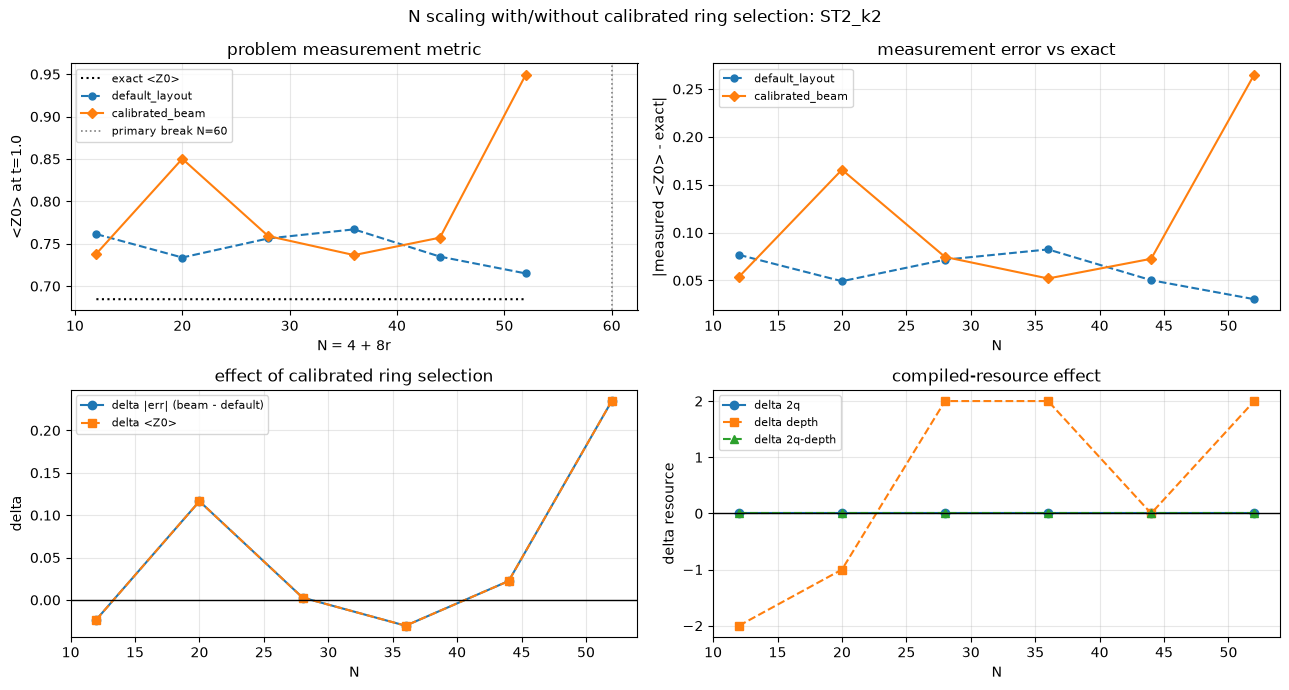

primary resource-break comparison: ST2_k3 breaks at N=44; ST2_k2 breaks at N=60


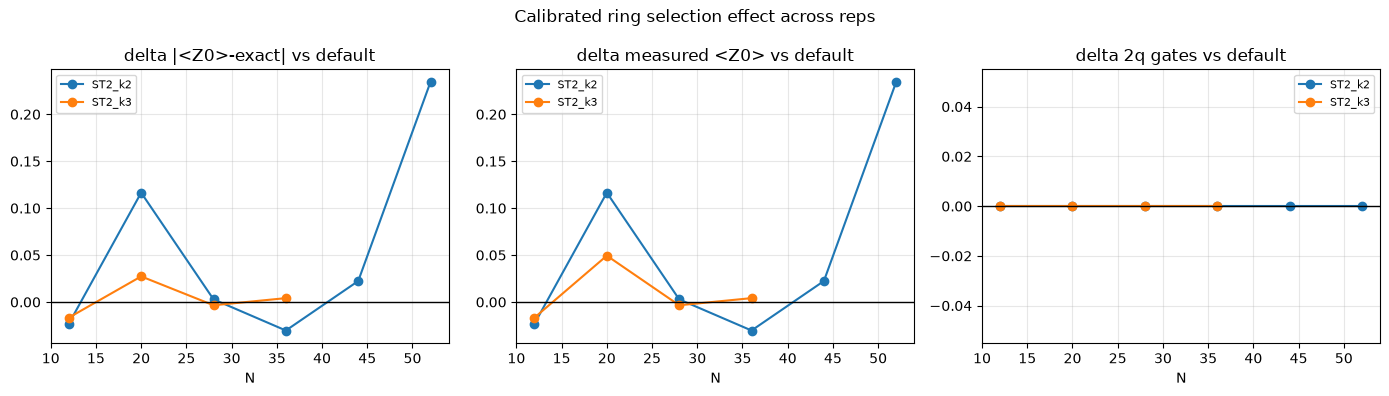

In [ ]:
# Same primary-break hierarchy as ST2_k3; only reps changes.
scaleup_table_k2, break_info_k2, qpu_stop_info_k2 = run_scaleup_experiment("ST2_k2", reps=2)

if break_info is not None and break_info_k2 is not None:
    print("primary resource-break comparison: ST2_k3 breaks at N=%d; ST2_k2 breaks at N=%d"
          % (break_info["N"], break_info_k2["N"]))

plot_combined_ring_selection_effect(SCALING_RESULTS)


## Problem 2(a): exact autocorrelation
$A(t)=\langle\psi_0|e^{-iHt}|\psi_0\rangle=\sum_n|\langle E_n|\psi_0\rangle|^2 e^{-iE_n t}$.

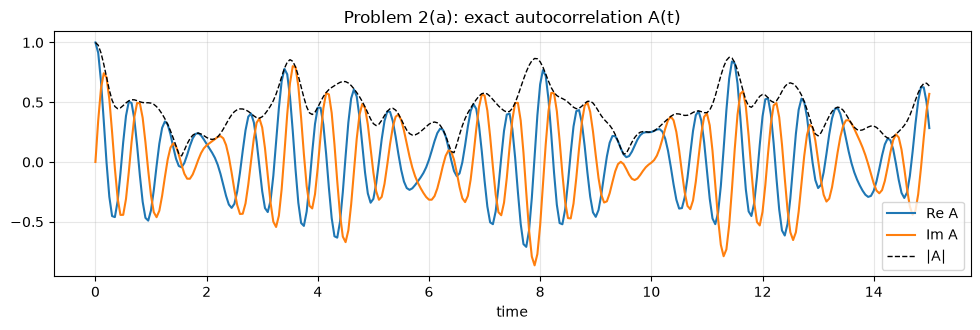

A(0) = 1.0 | max|A| = 1.0


In [ ]:
A_exact = np.array([psi0.data.conj() @ exact_state(t).data for t in TIMES])
fig, ax = plt.subplots(figsize=(10, 3.4))
ax.plot(TIMES, A_exact.real, label="Re A"); ax.plot(TIMES, A_exact.imag, label="Im A")
ax.plot(TIMES, np.abs(A_exact), "k--", lw=1, label="|A|")
ax.set_xlabel("time"); ax.set_title("Problem 2(a): exact autocorrelation A(t)"); ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()
print("A(0) =", round(A_exact[0].real, 6), "| max|A| =", round(np.max(np.abs(A_exact)), 4))

## Problem 2(b-c): Trotterized autocorrelation
$A_{PF}=\langle\psi_0|U_{PF}|\psi_0\rangle$. statevector overlap을 1차로 쓰고, Hadamard-test 회로로 교차검증.

Hadamard-test (controlled-U_PF) vs direct <psi0|U_PF|psi0>  [ST2_k3]:
    t    Re(direct)    Im(direct)      Re(HT)      Im(HT)      |err|
  0.0      1.000000      0.000000    1.000000   -0.000000    6.7e-15
  0.5      0.126247     -0.453657    0.126247   -0.453657    1.7e-15
  1.0     -0.457897     -0.051450   -0.457897   -0.051450    5.1e-15
  2.0     -0.281060     -0.170828   -0.281060   -0.170828    2.5e-15


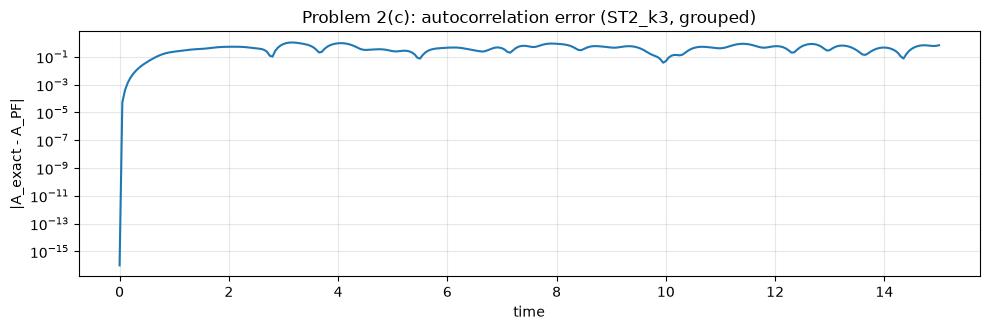

In [ ]:
A_SYN = SETTINGS["ST2_k3"]          # N=6 accuracy/depth balance; matches teammate's chosen model
A_SYN_NAME = "ST2_k3"

def A_pf_overlap(t):
    return complex(psi0.data.conj() @ product_formula_state(t, A_SYN, ordering="grouped").data)

def A_pf_hadamard(t, part="real"):
    # Genuine Hadamard-test circuit: ancilla controls the product-formula gate (guide 2(b)).
    cU = PauliEvolutionGate(get_H(N, "grouped"), time=float(t), synthesis=A_SYN).control(1)
    qc = QuantumCircuit(N + 1)               # qubits 0..N-1 = system, qubit N = ancilla
    state_prep(qc); qc.h(N)
    if part == "imag": qc.sdg(N)
    qc.append(cU, [N] + list(range(N))); qc.h(N)
    p = Statevector.from_instruction(qc.decompose(reps=4)).probabilities([N])
    return p[0] - p[1]

# Verification: Hadamard-test circuit vs direct overlap (printed table)
print("Hadamard-test (controlled-U_PF) vs direct <psi0|U_PF|psi0>  [%s]:" % A_SYN_NAME)
print("%5s  %12s  %12s  %10s  %10s  %9s" % ("t", "Re(direct)", "Im(direct)", "Re(HT)", "Im(HT)", "|err|"))
for tv in [0.0, 0.5, 1.0, 2.0]:
    d = A_pf_overlap(tv); h = A_pf_hadamard(tv, "real") + 1j * A_pf_hadamard(tv, "imag")
    print("%5.1f  %12.6f  %12.6f  %10.6f  %10.6f  %9.1e" % (tv, d.real, d.imag, h.real, h.imag, abs(d - h)))

A_pf = np.array([A_pf_overlap(t) for t in TIMES])   # full series via overlap (fast, equals HT)
eps_A = np.abs(A_exact - A_pf)
fig, ax = plt.subplots(figsize=(10, 3.4))
ax.semilogy(TIMES, np.maximum(eps_A, 1e-16)); ax.set_xlabel("time"); ax.set_ylabel("|A_exact - A_PF|")
ax.set_title("Problem 2(c): autocorrelation error (%s, grouped)" % A_SYN_NAME); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

## Problem 2(d-e): Fourier spectrum
$A(t)$의 DFT peak는 초기상태와 overlap이 nonzero인 eigenenergy 위치에 나타난다. 분해능 $\Delta E=2\pi/T_{max}$.

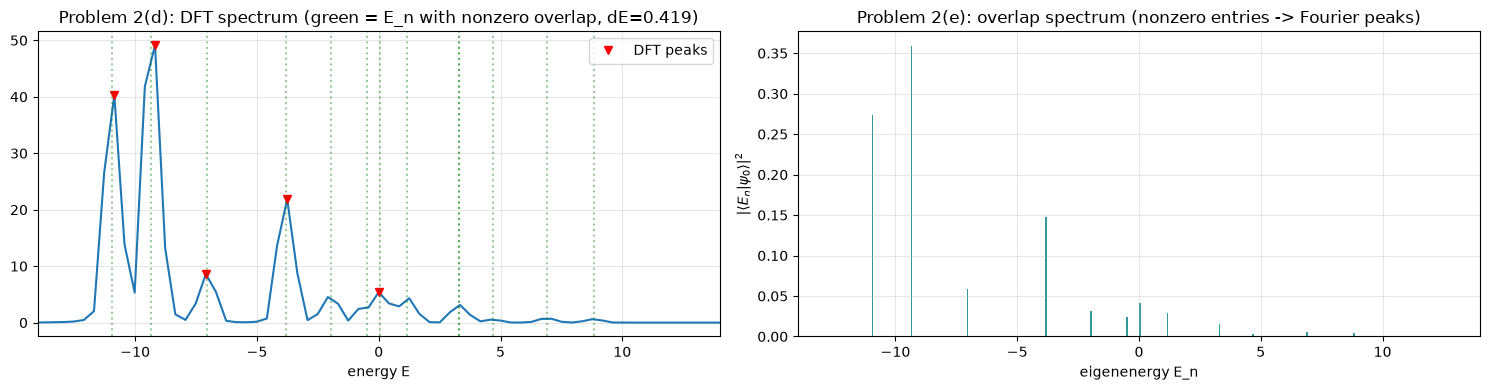

Dominant eigenenergies (|<E_n|psi0>|^2 > 1%):
       E_n    |<E_n|psi0>|^2  visible in DFT
   -9.3407            0.3591             YES
  -10.9374            0.2736             YES
   -3.8190            0.1477             YES
   -7.0314            0.0582             YES
    0.0332            0.0414             YES
   -1.9760            0.0317             YES
    1.1652            0.0295             YES
   -0.4966            0.0247             YES
    3.2976            0.0155             YES
    3.2991            0.0055             YES
    6.8991            0.0053             YES
    8.8341            0.0041             YES
    4.6726            0.0037             YES


,peak_energy,nearest_eigenvalue,overlap_weight,matched_2dE
0,-10.855,-10.937,0.274,True
1,-9.185,-9.341,0.359,True
2,-7.097,-7.031,0.058,True
3,-3.757,-3.819,0.148,True
4,-0.000,0.033,0.041,True


In [ ]:
from scipy.signal import find_peaks
window = np.hanning(len(A_exact))
spectrum = fftshift(fft(A_exact * window))
energy   = -2*np.pi * fftshift(fftfreq(len(A_exact), d=DT_GRID))     # A(t)=sum |c_n|^2 e^{-i E_n t}
dE = 2*np.pi / T_MAX
order = np.argsort(energy); energy, mag = energy[order], np.abs(spectrum)[order]
pk, _ = find_peaks(mag, height=mag.max()*0.1)
top = pk[np.argsort(mag[pk])[::-1][:6]]; peakE = np.sort(energy[top])
w = np.abs(_c0)**2                        # |<E_n|psi0>|^2 overlap weights
peaks_tab = pd.DataFrame(dict(
    peak_energy=np.round(peakE, 3),
    nearest_eigenvalue=[round(float(eigvals[np.argmin(np.abs(eigvals-pe))]), 3) for pe in peakE],
    overlap_weight=[round(float(w[np.argmin(np.abs(eigvals-pe))]), 3) for pe in peakE]))
peaks_tab["matched_2dE"] = np.abs(peaks_tab.peak_energy - peaks_tab.nearest_eigenvalue) <= 2*dE

# Two panels: (left) DFT spectrum + eigenenergy markers; (right) overlap spectrum |<E_n|psi0>|^2
thr = 0.01 * w.max()
fig, (axL, axR) = plt.subplots(1, 2, figsize=(15, 4))
axL.plot(energy, mag)
axL.plot(peakE, [mag[np.argmin(np.abs(energy-pe))] for pe in peakE], "rv", label="DFT peaks")
for e in eigvals[w > thr]:
    axL.axvline(e, color="g", ls=":", alpha=.4)
axL.set_xlabel("energy E"); axL.set_xlim(-14, 14)
axL.set_title("Problem 2(d): DFT spectrum (green = E_n with nonzero overlap, dE=%.3f)" % dE)
axL.legend(); axL.grid(alpha=.3)
axR.bar(eigvals, w, width=0.06, color="teal", alpha=0.8)
axR.set_xlabel("eigenenergy E_n"); axR.set_ylabel(r"$|\langle E_n|\psi_0\rangle|^2$"); axR.set_xlim(-14, 14)
axR.set_title("Problem 2(e): overlap spectrum (nonzero entries -> Fourier peaks)")
axR.grid(alpha=.3)
plt.tight_layout(); plt.show()

# Dominant eigenenergies and whether each is visible in the DFT (answers 2(e))
print("Dominant eigenenergies (|<E_n|psi0>|^2 > 1%):")
print("%10s  %16s  %14s" % ("E_n", "|<E_n|psi0>|^2", "visible in DFT"))
for ev, ov in sorted(zip(eigvals, w), key=lambda x: -x[1]):
    if ov > thr:
        print("%10.4f  %16.4f  %14s" % (ev, ov, "YES"))
peaks_tab

## Sanity gate
모든 핵심 검증을 한 셀에서 재확인한다.

In [ ]:
checks = []
def chk(name, cond): checks.append((name, "PASS" if bool(cond) else "FAIL"))
chk("S1 Hermitian, 24 terms, periodic, same-H", np.allclose(H_spo.to_matrix(), H_spo.to_matrix().conj().T)
    and len(H_spo) == 24 and same_H)
chk("S2 convention & exact(0)=psi0", BITSTRING_QISKIT == BITSTRING_Q0_FIRST[::-1]
    and np.allclose(exact_state(0).data, psi0.data))
chk("S3 exact norm=1 & <Z> in [-1,1]", abs(np.linalg.norm(exact_state(9.1).data)-1) < 1e-9
    and np.all(np.abs(exact_z1) <= 1+1e-9))
chk("S4 PF has cx>0", transpile_to_basis(evolution_circuit(0.5, SETTINGS["LT_k1"], include_stateprep=True).decompose()).count_ops().get("cx",0) > 0)
chk("S5 opt-invariance <=1e-9", max_dev <= 1e-9)
chk("S7 resource t-invariant", _res(_evo_only(N,"grouped",5.0),0) == _res(_evo_only(N,"grouped",0.5),0))
chk("S8 A(0)=1, |A|<=1, peaks matched", abs(A_exact[0]-1) < 1e-12 and np.max(np.abs(A_exact)) <= 1+1e-9
    and bool(peaks_tab.matched_2dE.all()))
chk("S9 1g budget pass, leakage~0, Z0 sane", passes and leak < 1e-9 and abs(z0_pf - z0_exact) < 0.5)
sanity = pd.DataFrame(checks, columns=["sanity check", "result"])
print("ALL PASS:", bool((sanity.result == "PASS").all()))
sanity

ALL PASS: True


,sanity check,result
0,"S1 Hermitian, 24 terms, periodic, same-H",PASS
1,S2 convention & exact(0)=psi0,PASS
2,"S3 exact norm=1 & <Z> in [-1,1]",PASS
3,S4 PF has cx>0,PASS
4,S5 opt-invariance <=1e-9,PASS
5,S7 resource t-invariant,PASS
6,"S8 A(0)=1, |A|<=1, peaks matched",PASS
7,"S9 1g budget pass, leakage~0, Z0 sane",PASS
